# CardioFusion: exploração de dados

Exploração dos dados das primeiras 24 horas de UTI, para responder: **quais características clínicas, fisiológicas e laboratoriais apresentam evidência computacional para serem investigadas como potenciais biomarcadores prognósticos de mortalidade hospitalar em pacientes com insuficiência cardíaca?**

**A janela.** T0 é a entrada na UTI, e a janela vai até T0 mais 24 horas. Toda característica é derivada exclusivamente desse intervalo. O desfecho é a mortalidade hospitalar.

**Sem testes de hipótese, por escolha.** Esta etapa pergunta *o que investigar e por quê*, não *se os dados sustentam as hipóteses*. Os candidatos vêm da literatura, e a exploração descreve os dados sem julgá-los: testar candidatos escolhidos depois de ver o resultado seria circular. O relatório que acompanha a entrega traz o caso clínico, a revisão de literatura e a fundamentação de cada candidato.

> **Nota sobre as saídas.** Nenhuma célula imprime linhas individuais de pacientes. Identificadores do MIMIC (`subject_id`, `hadm_id`), datas de internação e raça não aparecem em nenhuma saída: o repositório é público e isso seria redistribuição de dado credenciado. Só há estatísticas agregadas.

## 1. Dados e ambiente computacional

O corte está em `data/cohort/cases/`, com um diretório por internação. Cada diretório tem `clinical_data.json`, com demografia, admissão e desfecho, e `laboratory.csv`, com o painel de 50 exames.

A célula abaixo lê os diretórios e monta as tabelas: uma linha por internação, e uma linha por par internação-exame.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)

DATA = Path("../data/cohort/cases")
OUTCOME = "obito_hospitalar"

registros, exames, series, vitais, glasgow = [], [], [], [], []
for pasta in sorted(p for p in DATA.iterdir() if p.is_dir()):
    dados = json.loads((pasta / "clinical_data.json").read_text())
    adm = dados["admissao"]
    registros.append(
        {
            "paciente_id": dados["paciente_id"],
            "idade": dados["demografia"]["idade"],
            "sexo": dados["demografia"]["sexo"],
            "tipo_admissao": adm["tipo"],
            "origem_admissao": adm.get("origem"),
            "desfecho": adm.get("desfecho"),
            OUTCOME: bool(adm["obito_hospitalar"]),
            "admissao_em": pd.to_datetime(adm["admissao_em"]),
            "alta_em": pd.to_datetime(adm["alta_em"]),
            "janela_inicio": pd.to_datetime(dados["uti"]["janela_inicio"]),
            "em_uti": bool(dados["uti"]["em_uti"]),
        }
    )
    lab = pd.read_csv(pasta / "laboratory.csv")
    lab.insert(0, "paciente_id", dados["paciente_id"])
    exames.append(lab)

    # série completa da janela: todas as medições, com a hora de cada coleta
    caminho_serie = pasta / "laboratory_series.csv"
    if caminho_serie.exists():
        serie = pd.read_csv(caminho_serie)
        serie.insert(0, "paciente_id", dados["paciente_id"])
        series.append(serie)

    # sinais vitais da mesma janela de 24h
    caminho_vitais = pasta / "vitals_series.csv"
    if caminho_vitais.exists():
        v = pd.read_csv(caminho_vitais)
        v.insert(0, "paciente_id", dados["paciente_id"])
        vitais.append(v)

    # Escala de Coma de Glasgow na mesma janela
    caminho_gcs = pasta / "gcs_series.csv"
    if caminho_gcs.exists():
        g = pd.read_csv(caminho_gcs)
        g.insert(0, "paciente_id", dados["paciente_id"])
        glasgow.append(g)

cohort = pd.DataFrame(registros)
# tempo de internação: só conhecido na alta, usado apenas para caracterizar
cohort["los_days"] = (cohort.alta_em - cohort.admissao_em).dt.total_seconds() / 86400

labs_long = pd.concat(exames, ignore_index=True)
labs_long["ausente"] = labs_long["ausente"].astype(bool)
labs_wide = labs_long.pivot(index="paciente_id", columns="exame", values="valor")
labs_pct = labs_long.pivot(index="paciente_id", columns="exame", values="percentil")

labs_series = pd.concat(series, ignore_index=True)
vitals_series = pd.concat(vitais, ignore_index=True)
gcs_series = pd.concat(glasgow, ignore_index=True)

n, n_obitos = len(cohort), int(cohort[OUTCOME].sum())
print(f"{n} internações, {n_obitos} óbitos ({n_obitos / n * 100:.1f}%)")
print(f"cohort: {cohort.shape} | labs_long: {labs_long.shape} | labs_wide: {labs_wide.shape}")
print(f"série laboratorial: {len(labs_series):,} medições com hora de coleta")
print(
    f"sinais vitais:     {len(vitals_series):,} medições em {vitals_series.paciente_id.nunique()} internações"
)

1000 internações, 165 óbitos (16.5%)
cohort: (1000, 12) | labs_long: (50000, 7) | labs_wide: (1000, 50)
série laboratorial: 73,182 medições com hora de coleta
sinais vitais:     165,667 medições em 1000 internações


## 2. Dicionário dos dados disponíveis

Dois dicionários: os campos clínicos do `clinical_data.json` e o painel laboratorial, com completude, mediana e amplitude de cada exame.

In [2]:
pd.DataFrame(
    {
        "campo": cohort.columns,
        "tipo": [str(cohort[c].dtype) for c in cohort.columns],
        "valores_distintos": [cohort[c].nunique() for c in cohort.columns],
        "preenchido_%": [round(cohort[c].notna().mean() * 100, 1) for c in cohort.columns],
    }
)

,campo,tipo,valores_distintos,preenchido_%
0,paciente_id,str,1000,100.0
1,idade,int64,66,100.0
2,sexo,str,2,100.0
3,tipo_admissao,str,7,100.0
4,origem_admissao,str,10,100.0
5,desfecho,str,10,99.5
6,obito_hospitalar,bool,2,100.0
7,admissao_em,datetime64[us],1000,100.0
8,alta_em,datetime64[us],1000,100.0
9,janela_inicio,datetime64[us],1000,100.0


In [3]:
dicionario_labs = (
    labs_long.groupby(["itemid", "exame"])
    .agg(
        n_ausente=("ausente", "sum"),
        minimo=("valor", "min"),
        mediana=("valor", "median"),
        maximo=("valor", "max"),
    )
    .reset_index()
)
dicionario_labs["completude_%"] = ((1 - dicionario_labs.n_ausente / n) * 100).round(1)
dicionario_labs.sort_values("completude_%", ascending=False).drop(columns="n_ausente")

,itemid,exame,minimo,mediana,maximo,completude_%
16,50912,Creatinine,0.40,1.30,22.10,98.3
22,50971,Potassium,2.00,4.20,9.50,98.3
23,50983,Sodium,113.00,138.00,156.00,98.2
24,51006,Urea Nitrogen,3.00,28.50,203.00,98.2
14,50902,Chloride,67.00,102.00,123.00,98.2
11,50882,Bicarbonate,5.00,24.00,50.00,98.0
17,50931,Glucose,25.00,129.00,1158.00,97.9
9,50868,Anion Gap,4.00,14.00,48.00,97.9
28,51221,Hematocrit,14.50,30.90,58.10,97.3
37,51265,Platelet Count,20.00,192.00,1191.00,97.3


## 3. Caracterização da coorte

Quem são esses pacientes: tamanho, desfecho, idade, sexo e via de entrada.

In [4]:
print(f"Internações: {n}")
print(f"Óbito hospitalar: {n_obitos} ({cohort[OUTCOME].mean() * 100:.1f}%)")
print(
    f"Idade: média {cohort.idade.mean():.1f}, mediana {cohort.idade.median():.0f}, "
    f"min {cohort.idade.min()}, max {cohort.idade.max()}"
)
print(f"Passaram por UTI: {cohort.em_uti.all()} (critério da coorte)")
print()
print(cohort.sexo.value_counts().to_string())
print()
print(cohort.tipo_admissao.value_counts().to_string())

Internações: 1000
Óbito hospitalar: 165 (16.5%)
Idade: média 72.8, mediana 74, min 27, max 98
Passaram por UTI: True (critério da coorte)

sexo
M    546
F    454

tipo_admissao
EW EMER.                       515
URGENT                         220
OBSERVATION ADMIT              132
SURGICAL SAME DAY ADMISSION     52
DIRECT EMER.                    46
ELECTIVE                        31
EU OBSERVATION                   4


Idade mediana: 73 anos entre sobreviventes, 78 entre óbitos


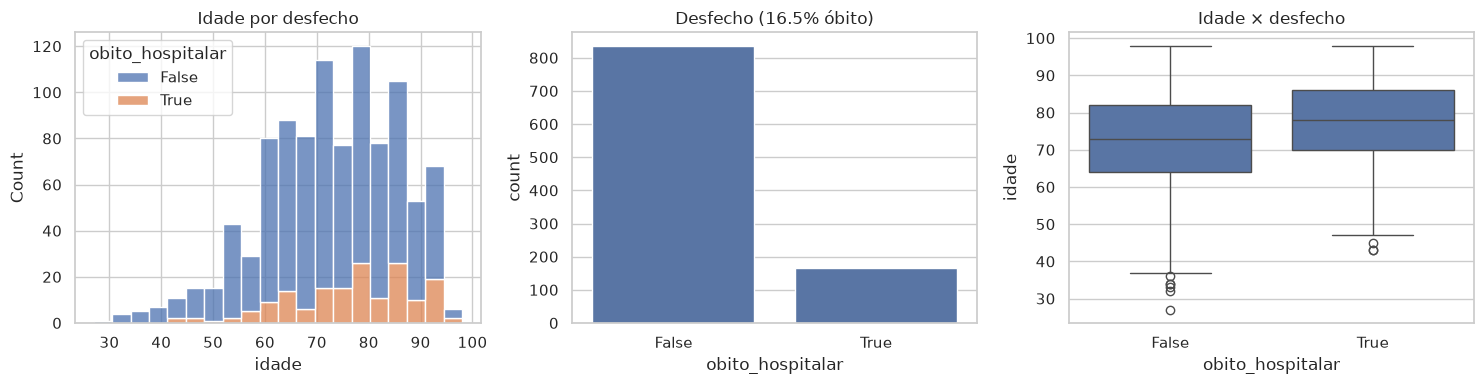

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(data=cohort, x="idade", hue=OUTCOME, multiple="stack", bins=20, ax=axes[0])
axes[0].set_title("Idade por desfecho")

sns.countplot(data=cohort, x=OUTCOME, ax=axes[1])
axes[1].set_title(f"Desfecho ({cohort[OUTCOME].mean() * 100:.1f}% óbito)")

sns.boxplot(data=cohort, x=OUTCOME, y="idade", ax=axes[2])
axes[2].set_title("Idade × desfecho")

plt.tight_layout()

print(
    f"Idade mediana: {cohort.loc[~cohort[OUTCOME], 'idade'].median():.0f} anos entre sobreviventes, "
    f"{cohort.loc[cohort[OUTCOME], 'idade'].median():.0f} entre óbitos"
)

> **Interpretação.** A idade separa os grupos de forma visível: mediana de 73 anos entre sobreviventes e 78 entre óbitos. O histograma mostra que os óbitos se concentram na cauda direita, e a caixa dos óbitos está deslocada para cima.
>
> Isso tem uma consequência que atravessa todo o resto do trabalho. Se pacientes mais velhos morrem mais **e** têm exames piores, qualquer diferença que encontrarmos num biomarcador pode ser idade disfarçada. Nenhum candidato pode ser avaliado sem separar as duas coisas, e é por isso que a idade entra como covariável obrigatória de ajuste, e não como candidato.
>
> A distribuição do desfecho, no painel do meio, mostra o desbalanceamento: cerca de um óbito para cada cinco sobreviventes. Isso condiciona a modelagem e é registrado nas limitações.

> **Atenção (vazamento de dados).** `desfecho`, que é o local de destino da alta, e `los_days`, o tempo de internação, só são conhecidos no fim da internação. São usados aqui apenas para caracterizar a coorte, nunca como preditores. Um modelo que os incluísse estaria olhando o futuro.

## 4. Qualidade dos dados e valores ausentes

A ausência de um exame não é ruído: alguns exames são de rotina e outros só são pedidos quando a equipe já suspeita de gravidade. Isso caracteriza um mecanismo de **ausência informativa** (MNAR, *missing not at random*): a própria falta do dado carrega informação clínica.

Esta seção descreve o padrão. A quantificação formal dessa associação é da etapa seguinte.

Faixas de completude:
  praticamente completos (>95%)    18 exames
  boa completude (80-95%)           5 exames
  parcial (50-80%)                  7 exames
  baixa (<50%)                     20 exames


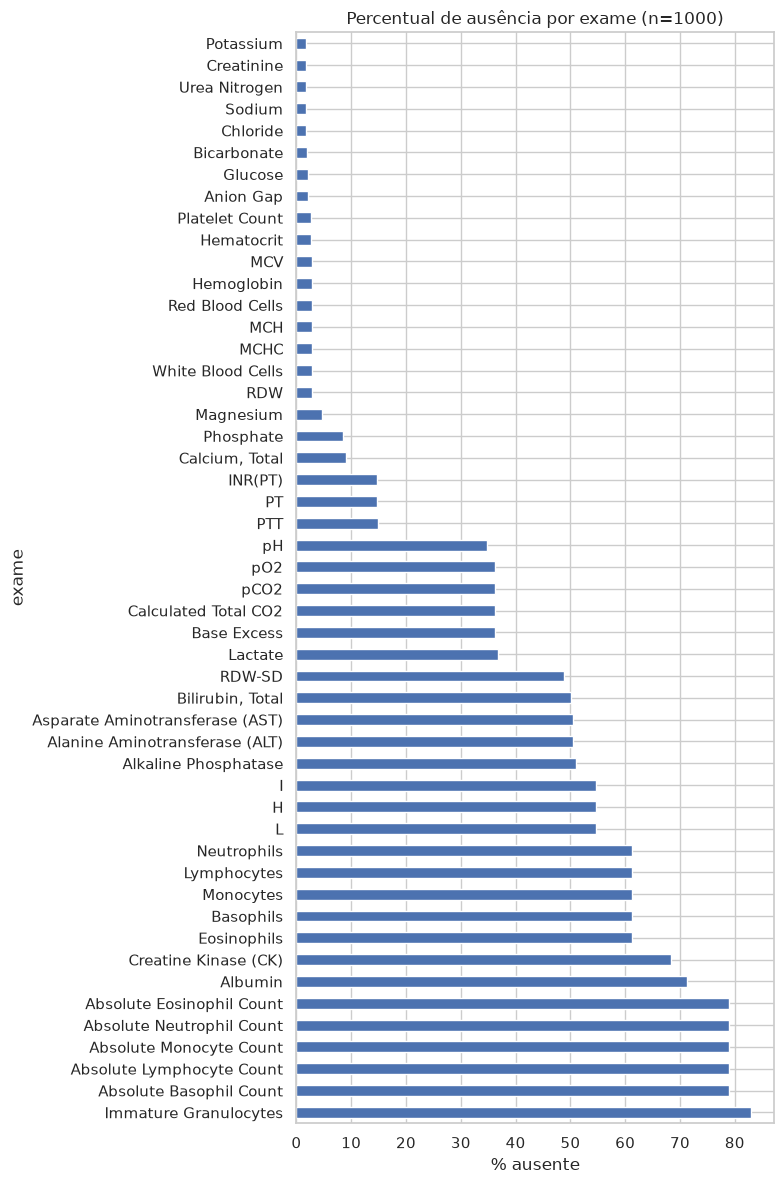

In [6]:
ausencia = labs_long.pivot(index="paciente_id", columns="exame", values="ausente")
pct_ausente = ausencia.mean().sort_values(ascending=False) * 100

plt.figure(figsize=(8, 12))
pct_ausente.plot.barh()
plt.xlabel("% ausente")
plt.title(f"Percentual de ausência por exame (n={n})")
plt.tight_layout()

print("Faixas de completude:")
for rotulo, minimo, maximo in [
    ("praticamente completos (>95%)", 95, 101),
    ("boa completude (80-95%)", 80, 95),
    ("parcial (50-80%)", 50, 80),
    ("baixa (<50%)", 0, 50),
]:
    completude = 100 - pct_ausente
    quantos = int(((completude >= minimo) & (completude < maximo)).sum())
    print(f"  {rotulo:32} {quantos:>2} exames")

> **Interpretação.** A completude cai em quatro faixas nítidas, e a divisão não é acidental: ela reproduz a rotina assistencial.
>
> Os 18 exames acima de 95% são o painel básico, hemograma e bioquímica, colhidos de praticamente todo paciente que entra na UTI. Os 20 abaixo de 50% são provas hepáticas, enzimas cardíacas, albumina e contagens absolutas, que dependem de alguém decidir solicitar.
>
> A consequência prática é que os candidatos não competem em igualdade. Um exame presente em 98% das internações sustenta análise sobre a coorte inteira; um presente em 39% sustenta análise sobre um subconjunto que pode não representar o todo. Essa diferença precisa acompanhar a leitura de qualquer resultado.

### 4.2 O padrão de ausência, não apenas o percentual

O gráfico anterior mostra *quanto* falta de cada exame. Este mostra *como* falta: cada linha é uma internação, cada coluna um exame, e o vermelho marca ausência.

O que procurar são as **faixas verticais contínuas**. Se dois exames faltam sempre nas mesmas internações, eles são solicitados juntos, o que revela a decisão clínica por trás. É a evidência visual do mecanismo de ausência informativa: gasometria arterial, lactato e provas hepáticas tendem a faltar em bloco, porque são pedidos em conjunto quando há suspeita de gravidade.

Exames ausentes por internação: mediana 17 de 50, min 0, max 50


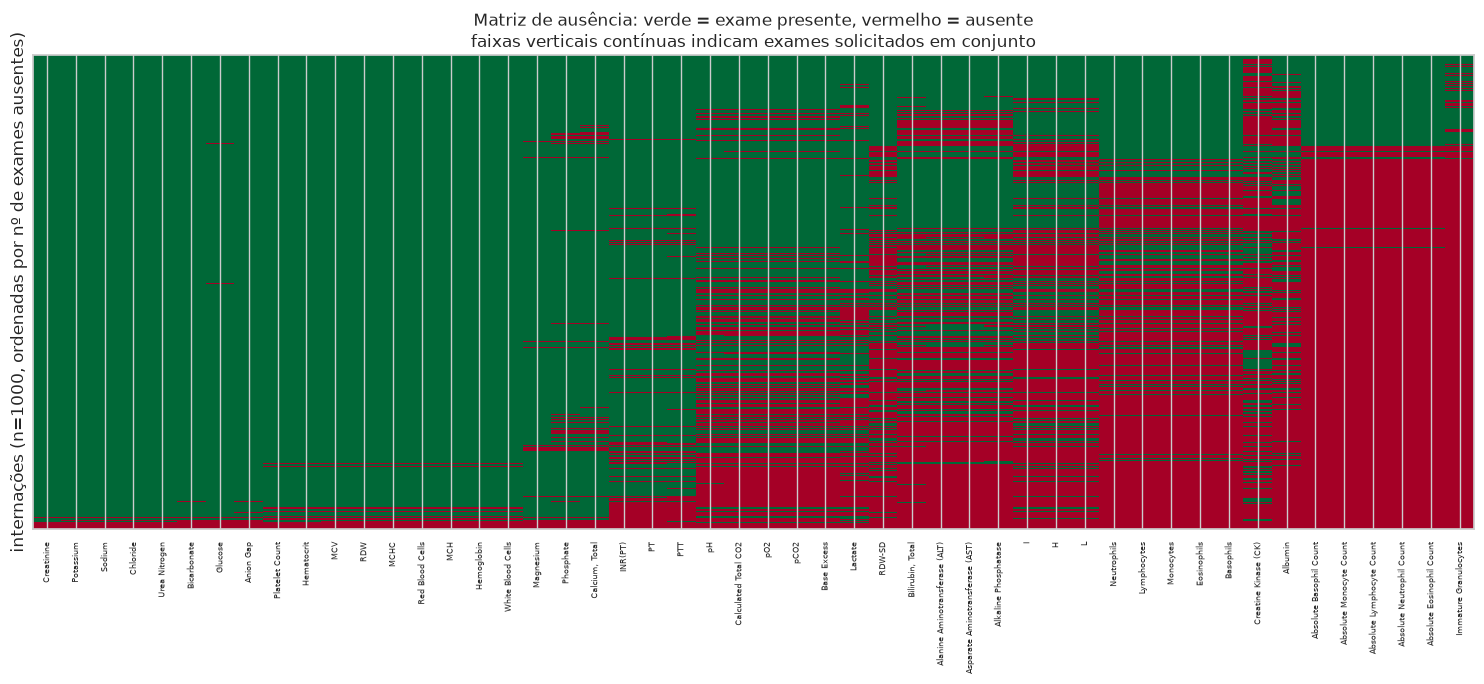

In [7]:
ordem_exames = ausencia.mean().sort_values().index
ordem_internacoes = ausencia[ordem_exames].sum(axis=1).sort_values().index
matriz = ausencia.loc[ordem_internacoes, ordem_exames]

fig, ax = plt.subplots(figsize=(15, 7))
ax.imshow(matriz.to_numpy(), aspect="auto", cmap="RdYlGn_r", interpolation="nearest")

ax.set_xticks(range(len(ordem_exames)))
ax.set_xticklabels(ordem_exames, rotation=90, fontsize=6)
ax.set_ylabel(f"internações (n={len(matriz)}, ordenadas por nº de exames ausentes)")
ax.set_yticks([])
ax.set_title(
    "Matriz de ausência: verde = exame presente, vermelho = ausente\n"
    "faixas verticais contínuas indicam exames solicitados em conjunto",
    fontsize=12,
)
plt.tight_layout()

# quantos exames faltam por internação
faltando = ausencia.sum(axis=1)
print(
    f"Exames ausentes por internação: mediana {faltando.median():.0f} de {ausencia.shape[1]}, "
    f"min {faltando.min()}, max {faltando.max()}"
)

> **Interpretação.** As faixas verticais são o que importa aqui, e elas aparecem com clareza no lado direito da matriz: blocos contínuos de vermelho, atravessando as mesmas internações.
>
> Isso significa que aqueles exames faltam **juntos**. Não é ausência aleatória espalhada: é ausência estruturada, que reflete a decisão de solicitar ou não um conjunto de exames de uma vez. Gasometria, lactato e provas hepáticas formam um desses blocos.
>
> A mediana de 17 exames ausentes por internação, de 50, mostra que a ausência é a regra e não a exceção. E a variação de 0 a 50 indica que as internações diferem muito no quanto foram investigadas, o que é por si só um marcador do julgamento clínico.
>
> Tratar essa ausência como aleatória, imputando valores como se os dados faltassem por acaso, introduziria viés na direção de suavizar justamente os pacientes mais graves.

### 4.3 Exames de rotina e exames pedidos sob suspeita

Comparação descritiva: qual a mortalidade entre quem teve o exame solicitado e entre quem não teve. Uma diferença grande sugere que a decisão de pedir o exame acompanha a percepção de gravidade da equipe.

**Cuidado na leitura.** Isso descreve o comportamento do serviço, não a fisiologia do paciente. Um modelo que usasse "pediram lactato" como preditor estaria aprendendo o julgamento do médico, não medindo o doente.

In [8]:
SENTINELA = [
    "Lactate",
    "pH",
    "pO2",
    "Albumin",
    "Alanine Aminotransferase (ALT)",
    "Creatine Kinase (CK)",
]

obito = cohort.set_index("paciente_id")[OUTCOME]
linhas = []
for exame in SENTINELA:
    pedido = labs_wide[exame].notna()
    d = obito.reindex(pedido.index)
    linhas.append(
        {
            "exame": exame,
            "n_pedido": int(pedido.sum()),
            "mortalidade_se_pedido_%": round(d[pedido].mean() * 100, 1),
            "mortalidade_se_nao_pedido_%": round(d[~pedido].mean() * 100, 1),
        }
    )

solicitacao = pd.DataFrame(linhas)
solicitacao["diferenca_pp"] = (
    solicitacao["mortalidade_se_pedido_%"] - solicitacao["mortalidade_se_nao_pedido_%"]
).round(1)
solicitacao.sort_values("diferenca_pp", ascending=False)

,exame,n_pedido,mortalidade_se_pedido_%,mortalidade_se_nao_pedido_%,diferenca_pp
1,pH,652,21.8,6.6,15.2
2,pO2,638,21.9,6.9,15.0
0,Lactate,632,20.9,9.0,11.9
4,Alanine Aminotransferase (ALT),485,20.4,12.8,7.6
5,Creatine Kinase (CK),317,19.9,14.9,5.0
3,Albumin,287,19.5,15.3,4.2


## 5. Exploração dos dados das primeiras 24 horas

Comparação descritiva de cada candidato entre sobreviventes e óbitos: medianas por grupo e a separação visual entre as distribuições.

Sem teste de hipótese, a leitura se apoia em duas coisas: a **diferença entre as medianas** e o **quanto as distribuições se sobrepõem**. Um exame cuja distribuição de óbitos cobre inteiramente a de sobreviventes não distingue os grupos, por maior que seja a diferença de mediana.

In [9]:
CANDIDATOS = [
    "Urea Nitrogen",
    "Creatinine",
    "Anion Gap",
    "Bicarbonate",
    "Lactate",
    "RDW",
    "Hemoglobin",
    "Sodium",
    "White Blood Cells",
    "Platelet Count",
]

df = labs_wide.join(obito)
linhas = []
for exame in CANDIDATOS:
    vivos = df.loc[~df[OUTCOME], exame].dropna()
    mortos = df.loc[df[OUTCOME], exame].dropna()
    linhas.append(
        {
            "exame": exame,
            "n_com_exame": len(vivos) + len(mortos),
            "mediana_sobreviventes": round(vivos.median(), 2),
            "mediana_obitos": round(mortos.median(), 2),
            "diferenca_%": round((mortos.median() - vivos.median()) / vivos.median() * 100, 1),
        }
    )

comparacao = pd.DataFrame(linhas)
comparacao["direcao"] = np.where(
    comparacao["diferenca_%"] > 0, "maior nos óbitos", "menor nos óbitos"
)
comparacao.reindex(comparacao["diferenca_%"].abs().sort_values(ascending=False).index)

,exame,n_com_exame,mediana_sobreviventes,mediana_obitos,diferenca_%,direcao
1,Creatinine,983,1.2,1.70,41.7,maior nos óbitos
0,Urea Nitrogen,982,27.0,37.00,37.0,maior nos óbitos
8,White Blood Cells,971,10.1,13.25,31.2,maior nos óbitos
2,Anion Gap,979,14.0,17.00,21.4,maior nos óbitos
4,Lactate,632,1.8,2.10,16.7,maior nos óbitos
3,Bicarbonate,979,24.0,21.00,-12.5,menor nos óbitos
5,RDW,971,15.1,16.50,9.3,maior nos óbitos
9,Platelet Count,973,192.0,199.50,3.9,maior nos óbitos
6,Hemoglobin,971,10.0,9.90,-1.0,menor nos óbitos
7,Sodium,982,138.0,138.00,0.0,menor nos óbitos


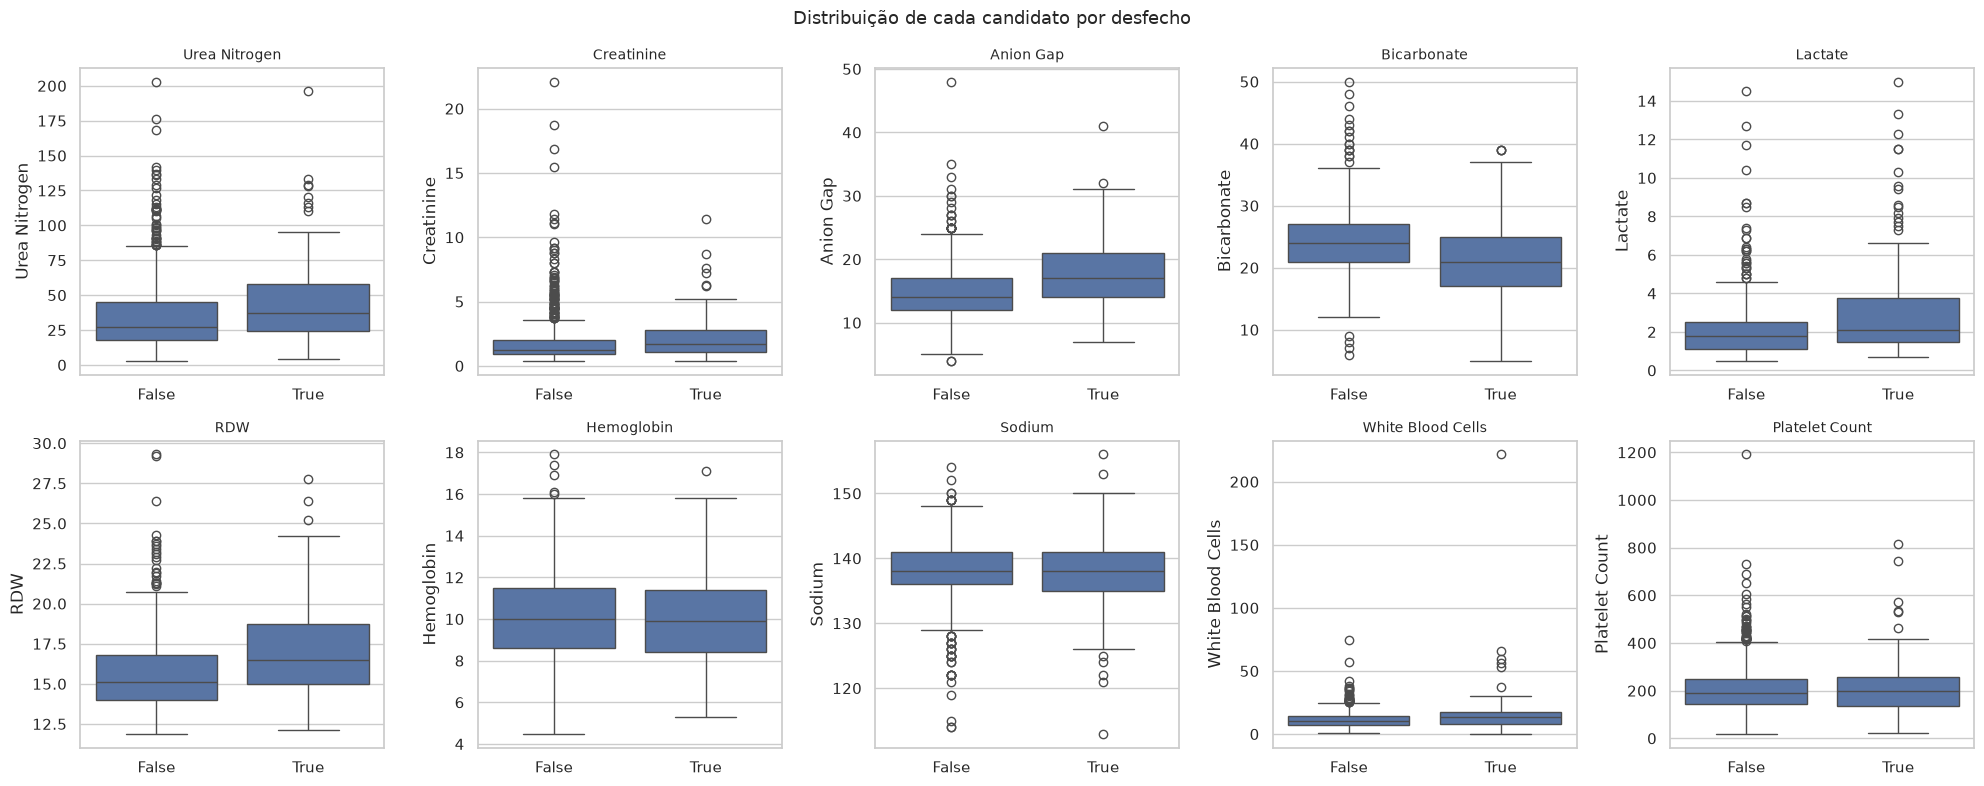

In [10]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
for ax, exame in zip(axes.flat, CANDIDATOS, strict=False):
    sns.boxplot(data=df, x=OUTCOME, y=exame, ax=ax)
    ax.set_title(exame, fontsize=10)
    ax.set_xlabel("")
fig.suptitle("Distribuição de cada candidato por desfecho", fontsize=13)
plt.tight_layout()

> **Interpretação.** Os deslocamentos entre as caixas são modestos em todos os dez painéis, e as distribuições se sobrepõem bastante. Nenhum exame isolado separa os grupos de forma limpa.
>
> Ainda assim, quatro deles mostram deslocamento consistente: ureia, creatinina e ânion gap mais altos entre os óbitos, bicarbonato mais baixo. Os três primeiros sobem quando os órgãos estão mal perfundidos; o bicarbonato desce porque é consumido neutralizando o ácido que a má perfusão produz. **São quatro leituras do mesmo fenômeno, e apontam na mesma direção.**
>
> Sódio, hemoglobina e plaquetas têm caixas praticamente sobrepostas. A leitura honesta é que não distinguem os desfechos nesta coorte.
>
> Repare também na altura das caixas: exames como ureia e creatinina têm dispersão muito maior entre os óbitos, o que indica que os pacientes que morrem são mais heterogêneos entre si do que os que sobrevivem.

### 5.1 Derivados compostos

Duas razões entre exames que a literatura sustenta. A razão ureia/creatinina separa o componente de hipoperfusão do de filtração renal; a razão neutrófilos/linfócitos indica inflamação sistêmica.

Ambas exigem os dois exames presentes, então a amostra é menor que a dos componentes isolados.

In [11]:
df["urea_creatinine_ratio"] = df["Urea Nitrogen"] / df["Creatinine"]
df["nlr"] = df["Neutrophils"] / df["Lymphocytes"]

for derivado in ["urea_creatinine_ratio", "nlr"]:
    vivos = df.loc[~df[OUTCOME], derivado].dropna()
    mortos = df.loc[df[OUTCOME], derivado].dropna()
    print(
        f"{derivado:24} mediana {vivos.median():>6.1f} (sobrev.) vs {mortos.median():>6.1f} (óbitos)"
        f"  | n={len(vivos) + len(mortos)}, óbitos com o dado={len(mortos)}"
    )

urea_creatinine_ratio    mediana   20.0 (sobrev.) vs   21.7 (óbitos)  | n=982, óbitos com o dado=158
nlr                      mediana    8.2 (sobrev.) vs    9.5 (óbitos)  | n=386, óbitos com o dado=60


### 5.2 Onde os óbitos caem dentro da distribuição dos sobreviventes

O gráfico anterior compara resumos. Este mostra a distribuição completa dos sobreviventes em cinza, com cada óbito marcado em vermelho por cima.

É a leitura mais direta de quais candidatos separam os grupos: se os pontos vermelhos se espalham por toda a distribuição cinza, aquele exame não distingue os desfechos nesta coorte.

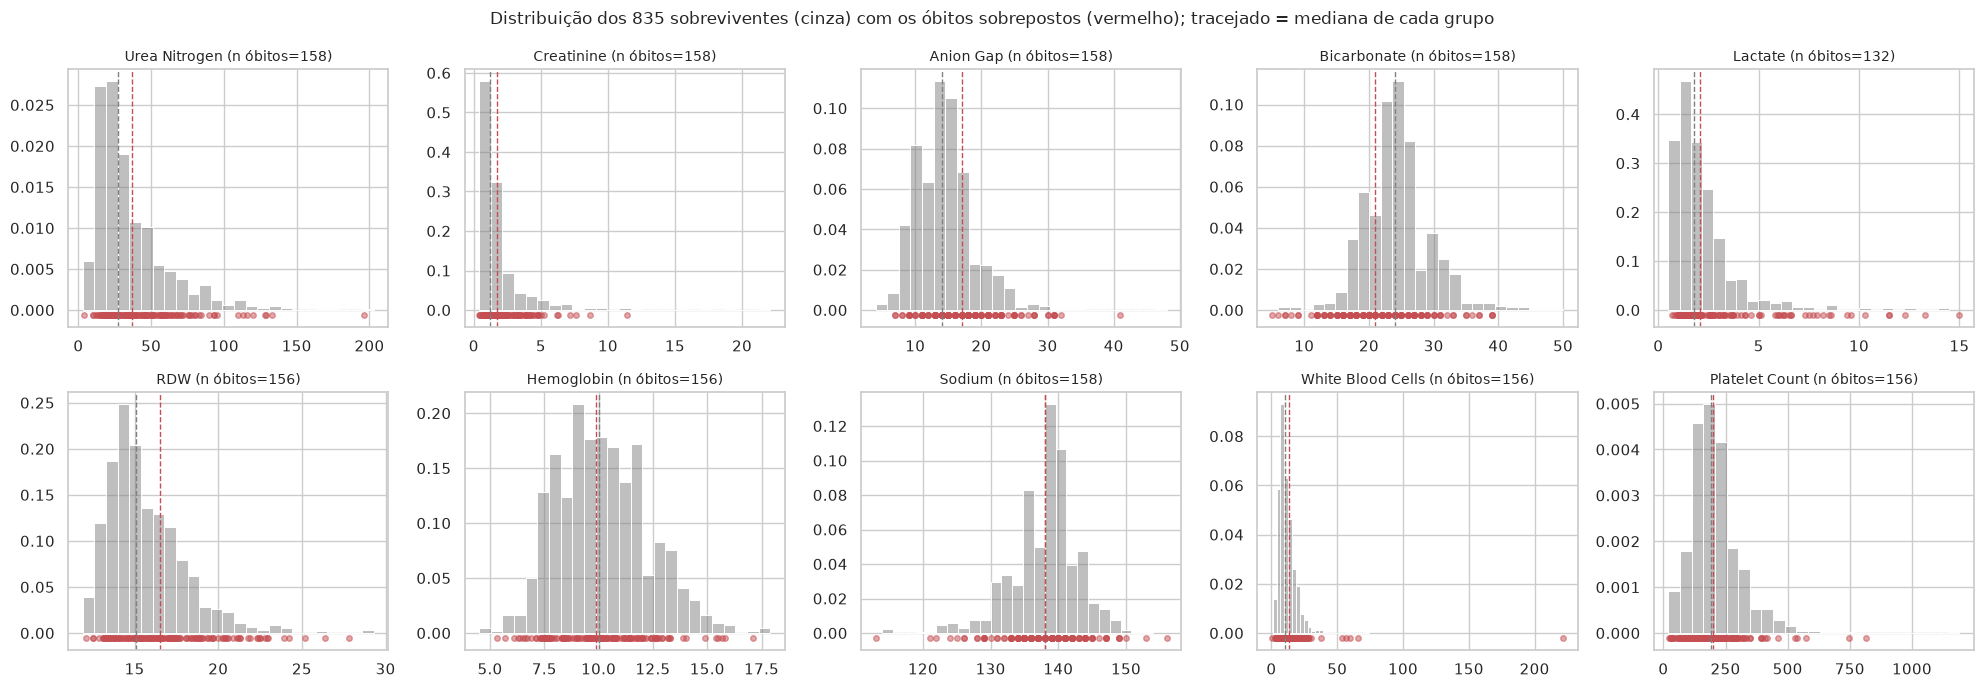

In [12]:
fig, axes = plt.subplots(2, 5, figsize=(20, 7))
n_sobreviventes = int((~df[OUTCOME]).sum())

for ax, exame in zip(axes.flat, CANDIDATOS, strict=False):
    vivos = df.loc[~df[OUTCOME], exame].dropna()
    mortos = df.loc[df[OUTCOME], exame].dropna()

    sns.histplot(vivos, ax=ax, color="gray", alpha=0.5, stat="density", bins=25)
    ax.plot(
        mortos,
        np.full(len(mortos), -0.02 * ax.get_ylim()[1]),
        "o",
        color="C3",
        markersize=4,
        alpha=0.5,
    )
    ax.axvline(vivos.median(), color="gray", linestyle="--", linewidth=1)
    ax.axvline(mortos.median(), color="C3", linestyle="--", linewidth=1)
    ax.set_title(f"{exame} (n óbitos={len(mortos)})", fontsize=10)
    ax.set_ylabel("")
    ax.set_xlabel("")

fig.suptitle(
    f"Distribuição dos {n_sobreviventes} sobreviventes (cinza) com os óbitos sobrepostos "
    "(vermelho); tracejado = mediana de cada grupo",
    fontsize=12,
)
plt.tight_layout()

> **Interpretação.** Esta é a leitura mais direta de separação. Cada ponto vermelho é um paciente que morreu, posicionado sobre a distribuição de quem sobreviveu.
>
> Onde os pontos vermelhos se espalham por toda a área cinza, como em sódio e hemoglobina, o exame não distingue nada: os óbitos ocupam exatamente as mesmas faixas de valor que os sobreviventes.
>
> Onde há acúmulo dos pontos numa das caudas, como em ureia, creatinina e ânion gap, existe sinal. Mas note que mesmo nesses casos há óbitos espalhados por toda a distribuição, **pacientes morrem com exames normais**, e nenhum ponto de corte capturaria todos.
>
> As linhas tracejadas mostram as medianas dos dois grupos. A distância entre elas é pequena comparada à largura das distribuições, o que resume a limitação de qualquer candidato isolado.

### 5.3 Perfil laboratorial dos pacientes que foram a óbito

Um painel por paciente, com os dez candidatos no eixo X, em percentil dentro do próprio corte. A padronização por percentil é necessária porque cada exame tem unidade e faixa própria, e sem ela os painéis não seriam comparáveis.

A linha tracejada em 0,5 é a mediana do corte. Pontos ausentes são exames não solicitados. Com muitos óbitos, são mostrados os primeiros doze; a grade completa seria ilegível.

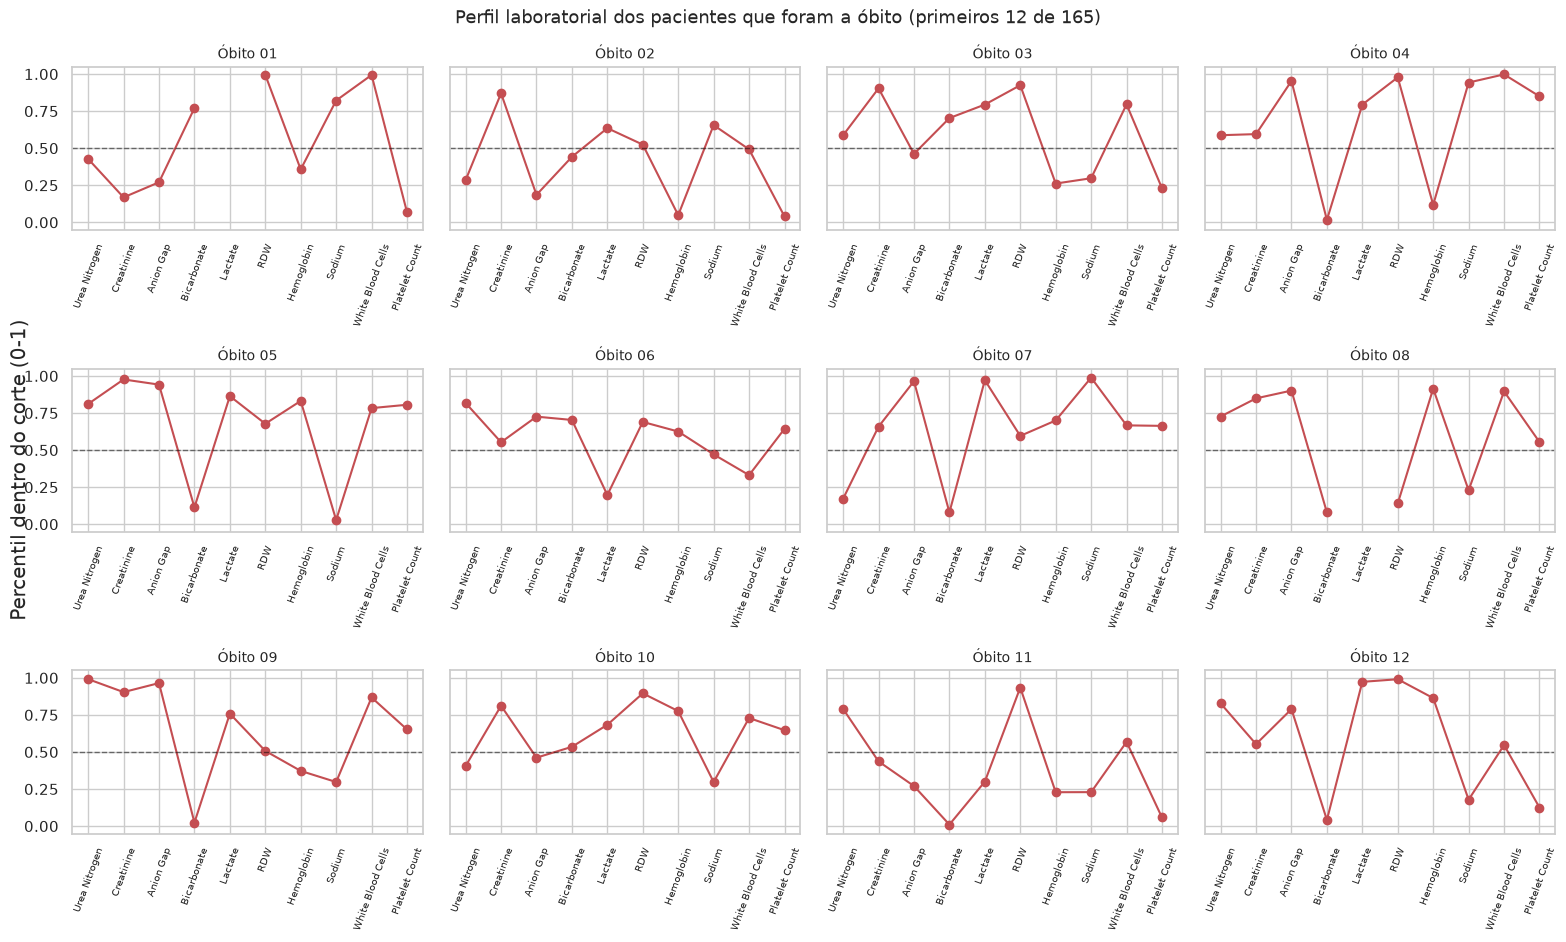

In [13]:
MAX_PAINEIS = 12
died_ids = cohort.loc[cohort[OUTCOME], "paciente_id"]
perfil = labs_pct.loc[labs_pct.index.isin(died_ids), CANDIDATOS]
mostrados = perfil.head(MAX_PAINEIS)

ncols = 4
nrows = -(-len(mostrados) // ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3.2 * nrows), sharey=True, squeeze=False)

for ax, (_, linha) in zip(axes.flat, mostrados.iterrows(), strict=False):
    ax.plot(CANDIDATOS, linha.to_numpy(), marker="o", color="C3")
    ax.axhline(0.5, color="black", linestyle="--", linewidth=1, alpha=0.5)
    ax.set_ylim(-0.05, 1.05)
    ax.tick_params(axis="x", rotation=70, labelsize=7)

for i, ax in enumerate(axes.flat):
    if i < len(mostrados):
        ax.set_title(f"Óbito {i + 1:02d}", fontsize=10)
    else:
        ax.axis("off")

fig.supylabel("Percentil dentro do corte (0-1)")
fig.suptitle(
    f"Perfil laboratorial dos pacientes que foram a óbito "
    f"(primeiros {len(mostrados)} de {len(perfil)})",
    fontsize=13,
)
plt.tight_layout()

> **Interpretação.** Cada painel é um paciente que morreu, e o que salta é a **heterogeneidade**: não existe um perfil único de quem evolui mal.
>
> Alguns painéis mostram a linha quase toda acima de 0,5, indicando um paciente alterado em quase tudo. Outros mostram a linha oscilando em torno da mediana do corte, ou seja, alguém que morreu com o quadro laboratorial próximo do normal.
>
> Isso tem uma implicação direta para a modelagem: se os pacientes que morrem não compartilham um padrão comum, nenhum conjunto pequeno de exames vai identificá-los todos. É um argumento a favor de combinar candidatos de eixos fisiológicos diferentes, em vez de apostar num só.

### 5.4 Quantos candidatos estavam alterados em cada paciente

Conta, por paciente que foi a óbito, quantos dos dez candidatos estavam em faixa extrema, definida como percentil acima de 0,75 ou abaixo de 0,25 dentro do corte.

Não é escore clínico validado. É uma leitura de quão alterado estava o quadro laboratorial, e de quanto os pacientes que morreram diferem entre si.

Alterações por paciente: mediana 5, min 0, max 10


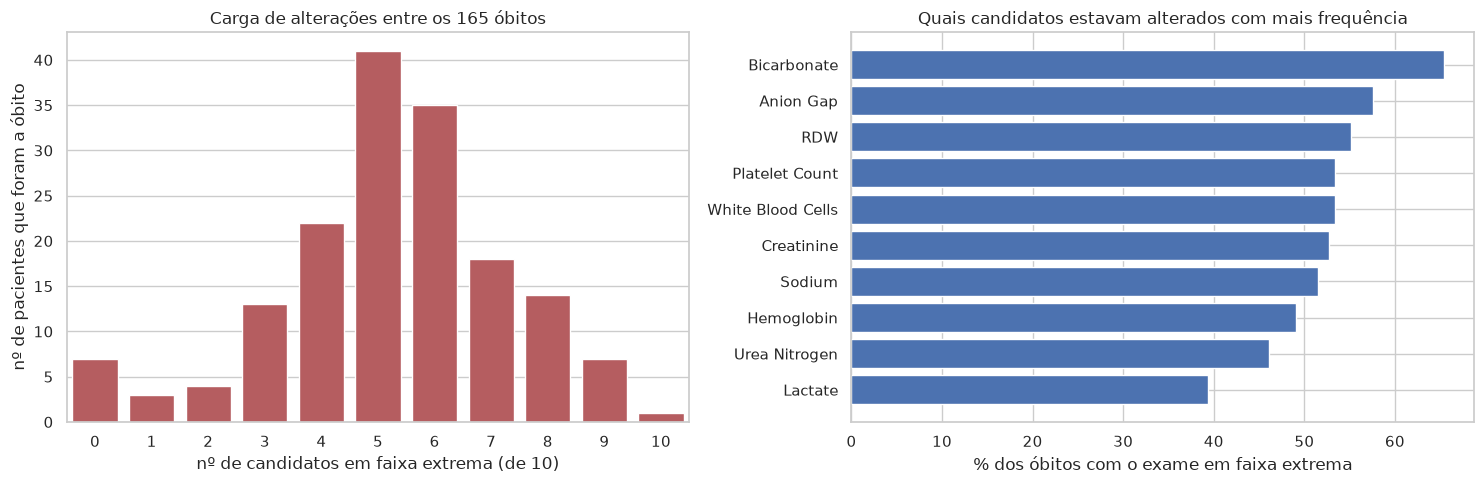

In [14]:
extremo = (perfil > 0.75) | (perfil < 0.25)
n_alterados = extremo.sum(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.countplot(x=n_alterados, ax=axes[0], color="C3")
axes[0].set_xlabel("nº de candidatos em faixa extrema (de 10)")
axes[0].set_ylabel("nº de pacientes que foram a óbito")
axes[0].set_title(f"Carga de alterações entre os {len(perfil)} óbitos")

frequencia = (extremo.sum() / len(perfil) * 100).sort_values()
axes[1].barh(frequencia.index, frequencia.to_numpy(), color="C0")
axes[1].set_xlabel("% dos óbitos com o exame em faixa extrema")
axes[1].set_title("Quais candidatos estavam alterados com mais frequência")

plt.tight_layout()

print(
    f"Alterações por paciente: mediana {n_alterados.median():.0f}, "
    f"min {n_alterados.min()}, max {n_alterados.max()}"
)

> **Interpretação.** O painel da esquerda quantifica a heterogeneidade que os perfis individuais sugeriram: a mediana é de 5 candidatos alterados por paciente, mas a variação vai de 1 a 10.
>
> Houve quem morresse com **um único** dos dez candidatos em faixa extrema. Se o critério de alerta fosse "muitos exames alterados", esse paciente passaria despercebido.
>
> O painel da direita mostra quais candidatos aparecem alterados com mais frequência entre os óbitos. Os que lideram são os mesmos que a comparação de medianas destacou, o que é uma confirmação por caminho diferente: não é artefato da escolha de mediana como resumo.

### 5.5 Tempo até o desfecho

`los_days` é o intervalo entre admissão e alta ou óbito. É a única variável genuinamente temporal fora da janela de 24h, e serve só para caracterizar a coorte: nunca como preditor, porque só é conhecida no fim da internação.

Dias até o óbito: mediana 6.4 (min 0.2, max 62.6)
Dias de internação dos sobreviventes: mediana 8.4


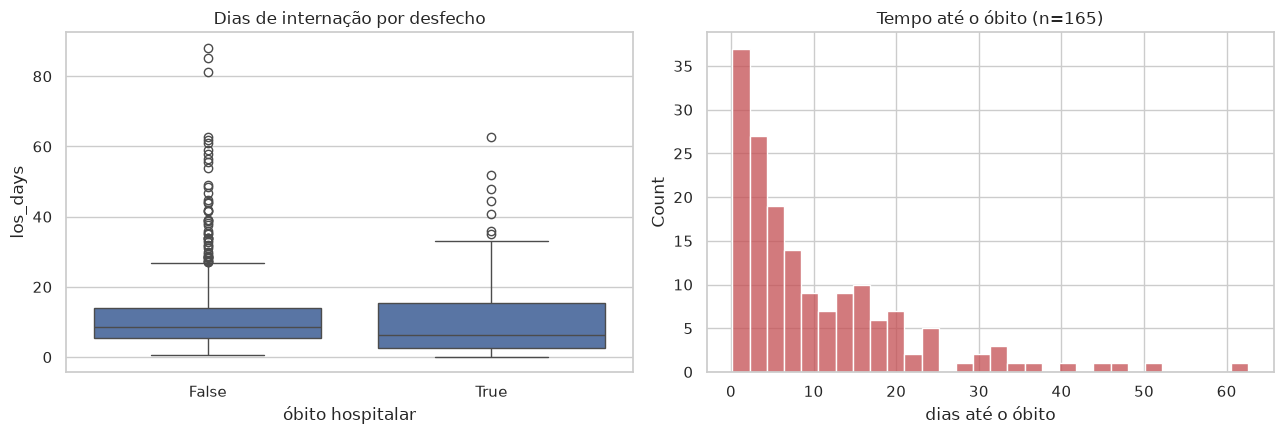

In [15]:
los = cohort.set_index("paciente_id")["los_days"]
los_obitos = los[los.index.isin(died_ids)]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.boxplot(x=obito.reindex(los.index), y=los, ax=axes[0])
axes[0].set_title("Dias de internação por desfecho")
axes[0].set_xlabel("óbito hospitalar")

sns.histplot(los_obitos, ax=axes[1], color="C3", bins=30)
axes[1].set_xlabel("dias até o óbito")
axes[1].set_title(f"Tempo até o óbito (n={len(los_obitos)})")

plt.tight_layout()

print(
    f"Dias até o óbito: mediana {los_obitos.median():.1f} "
    f"(min {los_obitos.min():.1f}, max {los_obitos.max():.1f})"
)
print(
    f"Dias de internação dos sobreviventes: mediana {los[~los.index.isin(died_ids)].median():.1f}"
)

> **Interpretação.** O tempo até o óbito tem mediana de 6,4 dias, e a distribuição é fortemente assimétrica: a maioria morre nos primeiros dias, mas há casos que se estendem por até 62,6 dias.
>
> O dado contraintuitivo é que **os sobreviventes ficam mais tempo internados** (mediana 8,4 dias contra 6,4). Isso não significa que internar menos protege. Significa que morrer encerra a internação: quem morre cedo tem permanência curta por definição, enquanto quem sobrevive completa o tratamento.
>
> É exatamente por isso que o tempo de permanência **não pode entrar como preditor**. Ele é consequência do desfecho, não causa, e um modelo que o usasse estaria olhando para o futuro. Aqui serve só para caracterizar a coorte.

## 6. Comportamento temporal na janela de 24h

Cada exame pode ter sido medido várias vezes dentro das primeiras 24 horas, e o corte preserva a hora de cada coleta na coluna `horas_da_janela`.

Isso permite a distinção que o enunciado pede entre **biomarcadores estáticos**, uma medida pontual, e **dinâmicos**, derivados da evolução da variável na janela. Esta seção descreve o que a série permite; a comparação formal entre as duas formas é da etapa seguinte.

In [16]:
# `laboratory.csv` traz um valor por exame; a série completa está em
# `laboratory_series.csv`, e é ela que sustenta a análise temporal
medidos = labs_series.copy()

por_par = (
    medidos.groupby(["paciente_id", "exame"])
    .agg(n_medicoes=("valor", "size"), primeira_hora=("horas_da_janela", "min"))
    .reset_index()
)

print(f"{len(medidos):,} medições em {medidos.paciente_id.nunique():,} internações")
print(f"{len(por_par):,} pares internação-exame")
print(
    f"medições por par: mediana {por_par.n_medicoes.median():.0f}, "
    f"média {por_par.n_medicoes.mean():.2f}, máx {por_par.n_medicoes.max()}"
)
print(f"pares com 2+ medições (dinâmica calculável): {(por_par.n_medicoes >= 2).mean() * 100:.1f}%")
print(f"primeira coleta: mediana {por_par.primeira_hora.median():.1f}h após a entrada na UTI")

73,182 medições em 988 internações
33,381 pares internação-exame
medições por par: mediana 2, média 2.19, máx 18
pares com 2+ medições (dinâmica calculável): 60.0%
primeira coleta: mediana 2.7h após a entrada na UTI


### 6.1 Quando os exames são coletados dentro das 24 horas

Antes de derivar qualquer característica dinâmica é preciso saber se a janela é povoada ou se as medições se concentram na admissão. Um exame medido uma única vez, na primeira hora, não tem comportamento temporal a extrair: é estático por construção.

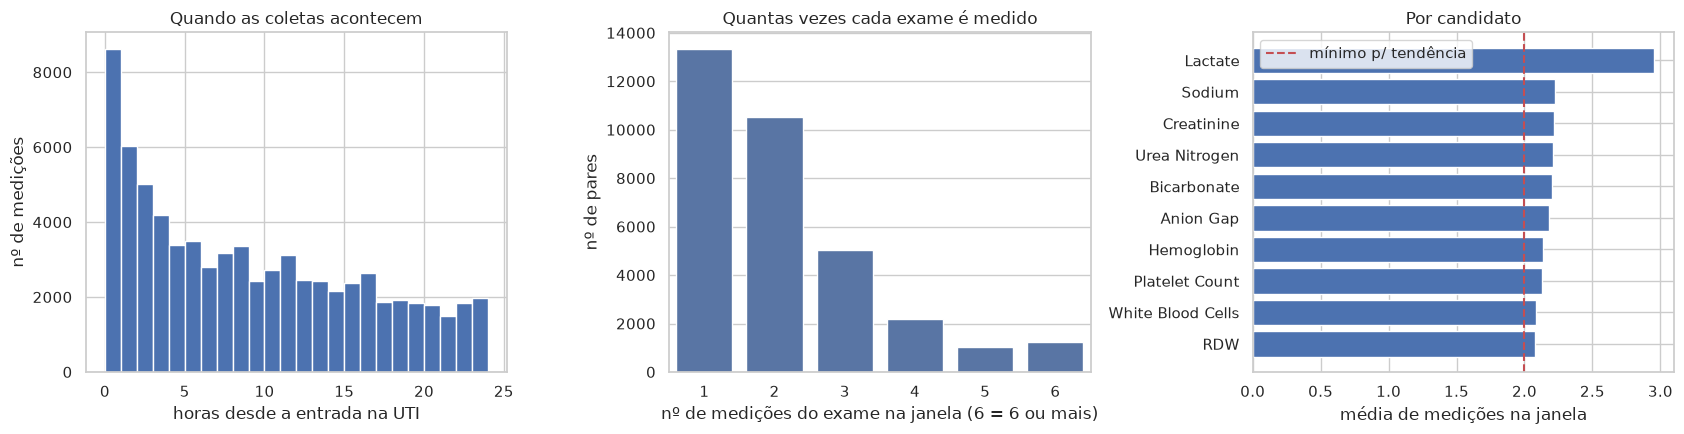

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

axes[0].hist(medidos.horas_da_janela.dropna(), bins=24, color="C0", edgecolor="white")
axes[0].set_xlabel("horas desde a entrada na UTI")
axes[0].set_ylabel("nº de medições")
axes[0].set_title("Quando as coletas acontecem")

sns.countplot(x=por_par.n_medicoes.clip(upper=6), ax=axes[1], color="C0")
axes[1].set_xlabel("nº de medições do exame na janela (6 = 6 ou mais)")
axes[1].set_ylabel("nº de pares")
axes[1].set_title("Quantas vezes cada exame é medido")

cobertura = (
    por_par[por_par.exame.isin(CANDIDATOS)]
    .groupby("exame")
    .n_medicoes.mean()
    .reindex(CANDIDATOS)
    .sort_values()
)
axes[2].barh(cobertura.index, cobertura.to_numpy(), color="C0")
axes[2].axvline(2, color="C3", linestyle="--", label="mínimo p/ tendência")
axes[2].set_xlabel("média de medições na janela")
axes[2].set_title("Por candidato")
axes[2].legend()

plt.tight_layout()

> **Interpretação.** O painel da esquerda mostra que as coletas não se distribuem uniformemente: há concentração nas primeiras horas, quando o paciente é admitido e recebe o painel inicial, e depois um segundo agrupamento na manhã seguinte, refletindo a rotina de coleta diária.
>
> O painel do meio mostra que a maioria dos pares internação-exame tem uma ou duas medições. Isso limita o que se pode extrair como característica dinâmica: com duas medições dá para calcular variação, mas a estimativa de tendência é frágil.
>
> O painel da direita indica quais candidatos têm medições suficientes para análise temporal. Os que ficam à esquerda da linha tracejada são, na prática, estáticos nesta janela: foram medidos uma vez só.

### 6.2 Evolução dos biomarcadores nas 24 horas, paciente a paciente

Valor no eixo Y, horas desde a entrada na UTI no eixo X, uma linha por internação.

São mostradas amostras aleatórias de internações com pelo menos duas medições do exame, separando quem foi a óbito de quem sobreviveu, para inspecionar visualmente se as trajetórias diferem.

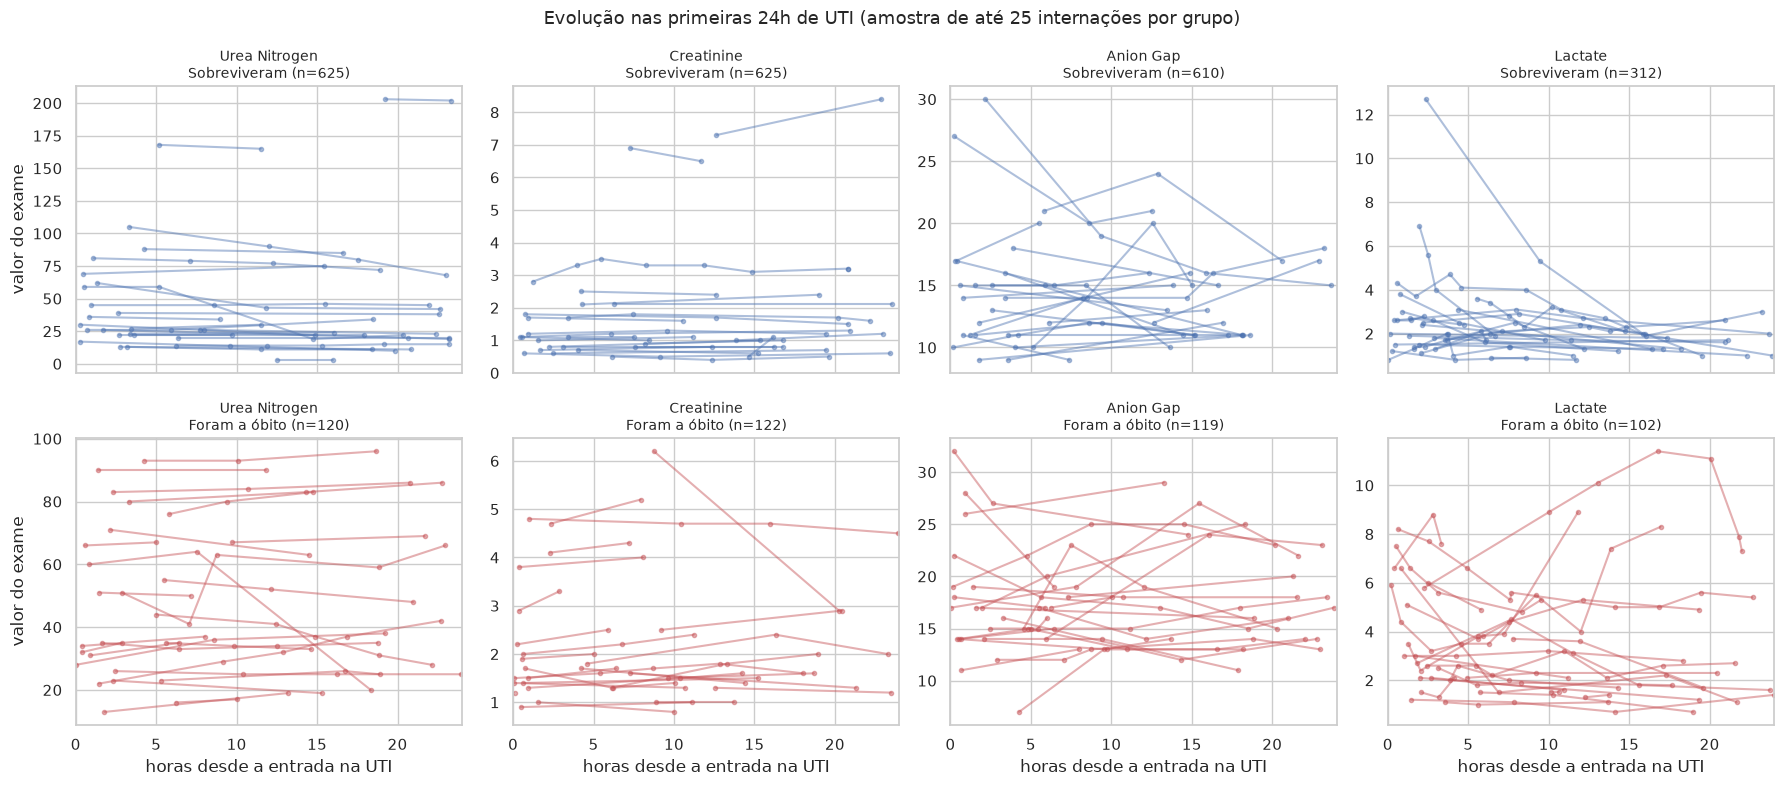

In [18]:
DESTAQUE = ["Urea Nitrogen", "Creatinine", "Anion Gap", "Lactate"]
N_LINHAS = 25
rng = np.random.default_rng(42)

fig, axes = plt.subplots(2, len(DESTAQUE), figsize=(4.5 * len(DESTAQUE), 8), sharex=True)

for col, exame in enumerate(DESTAQUE):
    sub = medidos[medidos.exame == exame]
    com_serie = sub.groupby("paciente_id").size()
    com_serie = com_serie[com_serie >= 2].index

    for linha, (morreu, titulo) in enumerate([(False, "Sobreviveram"), (True, "Foram a óbito")]):
        ax = axes[linha, col]
        elegiveis = [p for p in com_serie if obito.get(p) == morreu]
        escolhidos = rng.choice(elegiveis, size=min(N_LINHAS, len(elegiveis)), replace=False)

        for pid in escolhidos:
            traj = sub[sub.paciente_id == pid].sort_values("horas_da_janela")
            ax.plot(
                traj.horas_da_janela,
                traj.valor,
                marker="o",
                markersize=3,
                alpha=0.45,
                color="C3" if morreu else "C0",
            )
        ax.set_title(f"{exame}\n{titulo} (n={len(elegiveis)})", fontsize=10)
        ax.set_xlim(0, 24)
        if col == 0:
            ax.set_ylabel("valor do exame")
        if linha == 1:
            ax.set_xlabel("horas desde a entrada na UTI")

fig.suptitle(
    f"Evolução nas primeiras 24h de UTI (amostra de até {N_LINHAS} internações por grupo)",
    fontsize=13,
)
plt.tight_layout()

> **Interpretação.** Comparando a linha superior com a inferior, as trajetórias dos óbitos partem de patamares mais altos em ureia, creatinina e ânion gap, e a dispersão entre pacientes é maior.
>
> O que **não** se vê é um padrão de deterioração dentro das 24 horas. As linhas são majoritariamente planas nos dois grupos. Isso é informativo: o que distingue os desfechos parece ser o **nível** em que o paciente já se encontra ao entrar na UTI, e não a velocidade com que piora no primeiro dia.
>
> Faz sentido clínico. Um paciente que chega com ureia de 80 já vinha se deteriorando havia dias ou semanas antes da admissão; as 24 horas da janela capturam o resultado desse processo, não o processo em si.

### 6.3 O que a janela acrescenta sobre a medida de admissão

Para cada candidato, comparação descritiva entre o valor de chegada e o resumo do dia inteiro. A pergunta é se o pior valor alcançado, ou o nível sustentado, difere do valor de admissão de forma clinicamente relevante.

Sem teste formal, a leitura se apoia na diferença entre as medianas de cada grupo, para cada forma de olhar a mesma variável.

In [19]:
LEITURAS = {
    "inicial": "first",
    "média": "mean",
    "mínimo": "min",
    "máximo": "max",
}

serie = medidos[medidos.exame.isin(CANDIDATOS)].sort_values("horas_da_janela")
resumo = (
    serie.groupby(["paciente_id", "exame"])
    .valor.agg(list(LEITURAS.values()))
    .rename(columns={v: k for k, v in LEITURAS.items()})
    .reset_index()
)
resumo["morreu"] = resumo.paciente_id.map(obito)

linhas = []
for exame in CANDIDATOS:
    sub = resumo[resumo.exame == exame]
    entrada = {"exame": exame}
    for leitura in LEITURAS:
        vivos = sub.loc[~sub.morreu, leitura].median()
        mortos = sub.loc[sub.morreu, leitura].median()
        entrada[leitura] = round(mortos - vivos, 2)
    linhas.append(entrada)

print("Diferença entre a mediana dos óbitos e a dos sobreviventes, por forma de leitura:")
print("(valores positivos = mais alto em quem foi a óbito)\n")
pd.DataFrame(linhas).set_index("exame")

Diferença entre a mediana dos óbitos e a dos sobreviventes, por forma de leitura:
(valores positivos = mais alto em quem foi a óbito)



,inicial,média,mínimo,máximo
exame,,,,
Urea Nitrogen,10.00,12.75,8.50,14.00
Creatinine,0.50,0.67,0.50,0.70
Anion Gap,3.00,3.00,2.50,3.00
Bicarbonate,-3.00,-3.32,-3.50,-3.00
Lactate,0.30,0.49,0.40,0.50
RDW,1.40,1.47,1.45,1.40
Hemoglobin,-0.10,0.07,-0.10,-0.15
Sodium,0.00,-0.33,-1.00,0.00
White Blood Cells,3.15,3.26,2.80,3.45


## 7. Sinais vitais nas primeiras 24 horas

Os sinais vitais são medidos de forma contínua na UTI e registrados várias vezes por dia, ao contrário dos exames de sangue, que dependem de coleta. Esta seção descreve o que está disponível.

A literatura torna a pressão arterial especialmente relevante: no registro ADHERE, a pressão sistólica abaixo de 115 mmHg foi o **segundo melhor preditor** de mortalidade hospitalar em insuficiência cardíaca, atrás apenas da ureia. É a variável que sustenta uma quinta hipótese, de instabilidade hemodinâmica, ausente do quadro original por indisponibilidade do dado.

In [20]:
resumo_vitais = (
    vitals_series.groupby("sinal")
    .agg(
        medicoes=("valor", "size"),
        internacoes=("paciente_id", "nunique"),
        mediana=("valor", "median"),
        minimo=("valor", "min"),
        maximo=("valor", "max"),
    )
    .assign(cobertura_pct=lambda d: (d.internacoes / n * 100).round(1))
    .sort_values("cobertura_pct", ascending=False)
)
print(
    f"{len(vitals_series):,} medições em {vitals_series.paciente_id.nunique()} das {n} internações\n"
)
resumo_vitais.round(1)

165,667 medições em 1000 das 1000 internações



,medicoes,internacoes,mediana,minimo,maximo,cobertura_pct
sinal,,,,,,
Heart Rate,26977,1000,83.0,19.0,178.0,100.0
Respiratory Rate,26737,1000,19.0,2.0,67.0,100.0
SpO2,26428,999,97.0,31.0,100.0,99.9
Mean BP,25960,993,73.0,20.0,248.0,99.3
Diastolic BP,25946,992,59.0,11.0,190.0,99.2
Systolic BP,25945,992,111.0,35.0,233.0,99.2
Temperature,7674,958,36.7,29.4,40.2,95.8


### 7.1 Frequência de medição e a diferença para os exames de sangue

Os sinais vitais têm cobertura muito maior que os exames laboratoriais mais escassos: acima de 97% das internações, contra 64% do lactato e 37% do diferencial leucocitário. E são medidos muitas vezes ao longo do dia, o que os torna candidatos naturalmente dinâmicos.

Isso muda o perfil de disponibilidade da coorte e reduz, para essas variáveis, a preocupação com ausência informativa que a seção 4 levantou.

Medições por internação-sinal: mediana 25, máx 138


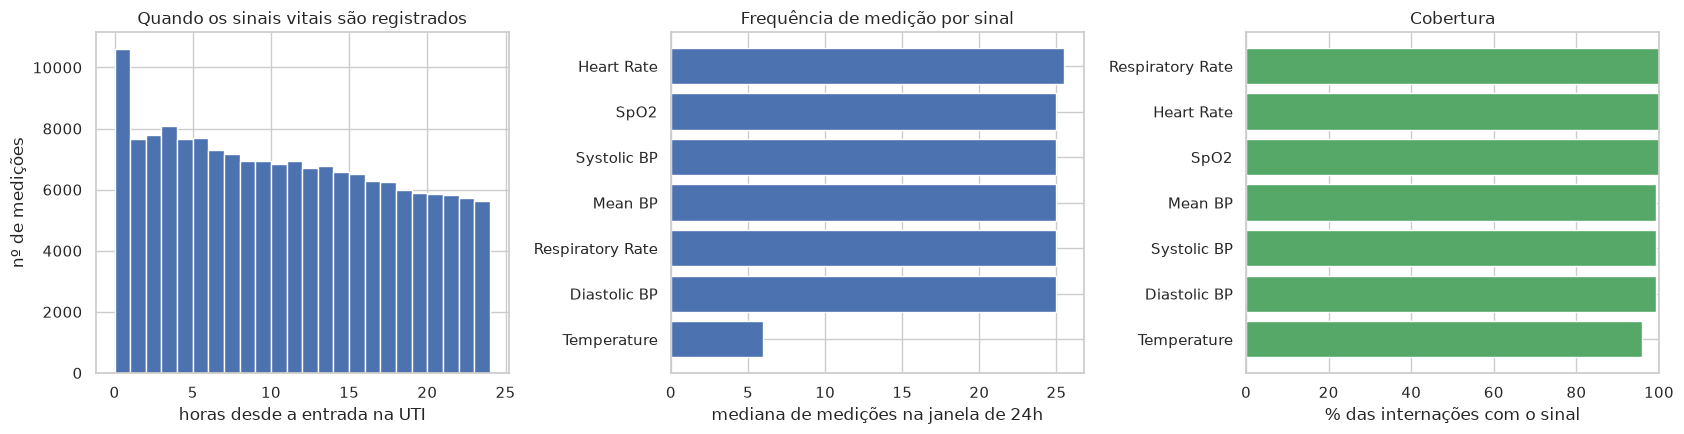

In [21]:
por_sinal = (
    vitals_series.groupby(["paciente_id", "sinal"]).agg(n_medicoes=("valor", "size")).reset_index()
)

fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

axes[0].hist(vitals_series.horas_da_janela, bins=24, color="C0", edgecolor="white")
axes[0].set_xlabel("horas desde a entrada na UTI")
axes[0].set_ylabel("nº de medições")
axes[0].set_title("Quando os sinais vitais são registrados")

medianas = por_sinal.groupby("sinal").n_medicoes.median().sort_values()
axes[1].barh(medianas.index, medianas.to_numpy(), color="C0")
axes[1].set_xlabel("mediana de medições na janela de 24h")
axes[1].set_title("Frequência de medição por sinal")

cobertura = (vitals_series.groupby("sinal").paciente_id.nunique() / n * 100).sort_values()
axes[2].barh(cobertura.index, cobertura.to_numpy(), color="C2")
axes[2].set_xlim(0, 100)
axes[2].set_xlabel("% das internações com o sinal")
axes[2].set_title("Cobertura")

plt.tight_layout()

print(
    f"Medições por internação-sinal: mediana {por_sinal.n_medicoes.median():.0f}, "
    f"máx {por_sinal.n_medicoes.max()}"
)

> **Interpretação.** A diferença de ritmo em relação aos exames de sangue é grande: mediana de 25 medições por sinal em cada internação, chegando a 138.
>
> Isso muda o que é possível extrair. Com 25 pontos ao longo de 24 horas dá para estimar média, mínimo, variabilidade e tendência com confiança razoável, o que não acontece com um exame medido uma ou duas vezes.
>
> A cobertura acima de 95% em todos os sinais também reduz, para eles, a preocupação com ausência informativa da seção 4. Sinais vitais vêm do monitor de forma contínua, sem depender de alguém decidir solicitar, então a ausência aqui costuma ser falha de registro e não decisão clínica.

### 7.2 Distribuição por desfecho

Comparação descritiva entre sobreviventes e óbitos, usando o **valor mais precoce** de cada sinal, que é o equivalente ao valor de admissão dos exames.

A linha de referência na pressão sistólica marca 115 mmHg, o corte do ADHERE.

In [22]:
SINAIS = ["Systolic BP", "Mean BP", "Heart Rate", "SpO2", "Respiratory Rate", "Temperature"]
# unidades, para os rótulos: a temperatura foi convertida de Fahrenheit na extração
UNIDADES = {
    "Systolic BP": "mmHg",
    "Mean BP": "mmHg",
    "Heart Rate": "bpm",
    "SpO2": "%",
    "Respiratory Rate": "irpm",
    "Temperature": "°C",
}

primeiro_vital = (
    vitals_series.sort_values("horas_da_janela")
    .groupby(["paciente_id", "sinal"])
    .valor.first()
    .unstack()
)
vitais_desfecho = primeiro_vital.join(obito)

linhas = []
for sinal in SINAIS:
    vivos = vitais_desfecho.loc[~vitais_desfecho[OUTCOME], sinal].dropna()
    mortos = vitais_desfecho.loc[vitais_desfecho[OUTCOME], sinal].dropna()
    linhas.append(
        {
            "sinal": f"{sinal} ({UNIDADES[sinal]})",
            "n_com_medida": len(vivos) + len(mortos),
            "mediana_sobreviventes": round(vivos.median(), 1),
            "mediana_obitos": round(mortos.median(), 1),
            "diferenca": round(mortos.median() - vivos.median(), 1),
        }
    )
pd.DataFrame(linhas)

,sinal,n_com_medida,mediana_sobreviventes,mediana_obitos,diferenca
0,Systolic BP (mmHg),992,120.0,111.0,-9.0
1,Mean BP (mmHg),993,80.0,76.0,-4.0
2,Heart Rate (bpm),1000,85.0,92.0,7.0
3,SpO2 (%),999,98.0,96.5,-1.5
4,Respiratory Rate (irpm),1000,19.0,20.0,1.0
5,Temperature (°C),958,36.7,36.6,-0.1


Internações com pressão sistólica de admissão abaixo de 115 mmHg: 445 de 992 (44.5%)
  mortalidade abaixo do corte: 19.3%
  mortalidade acima do corte:  14.2%


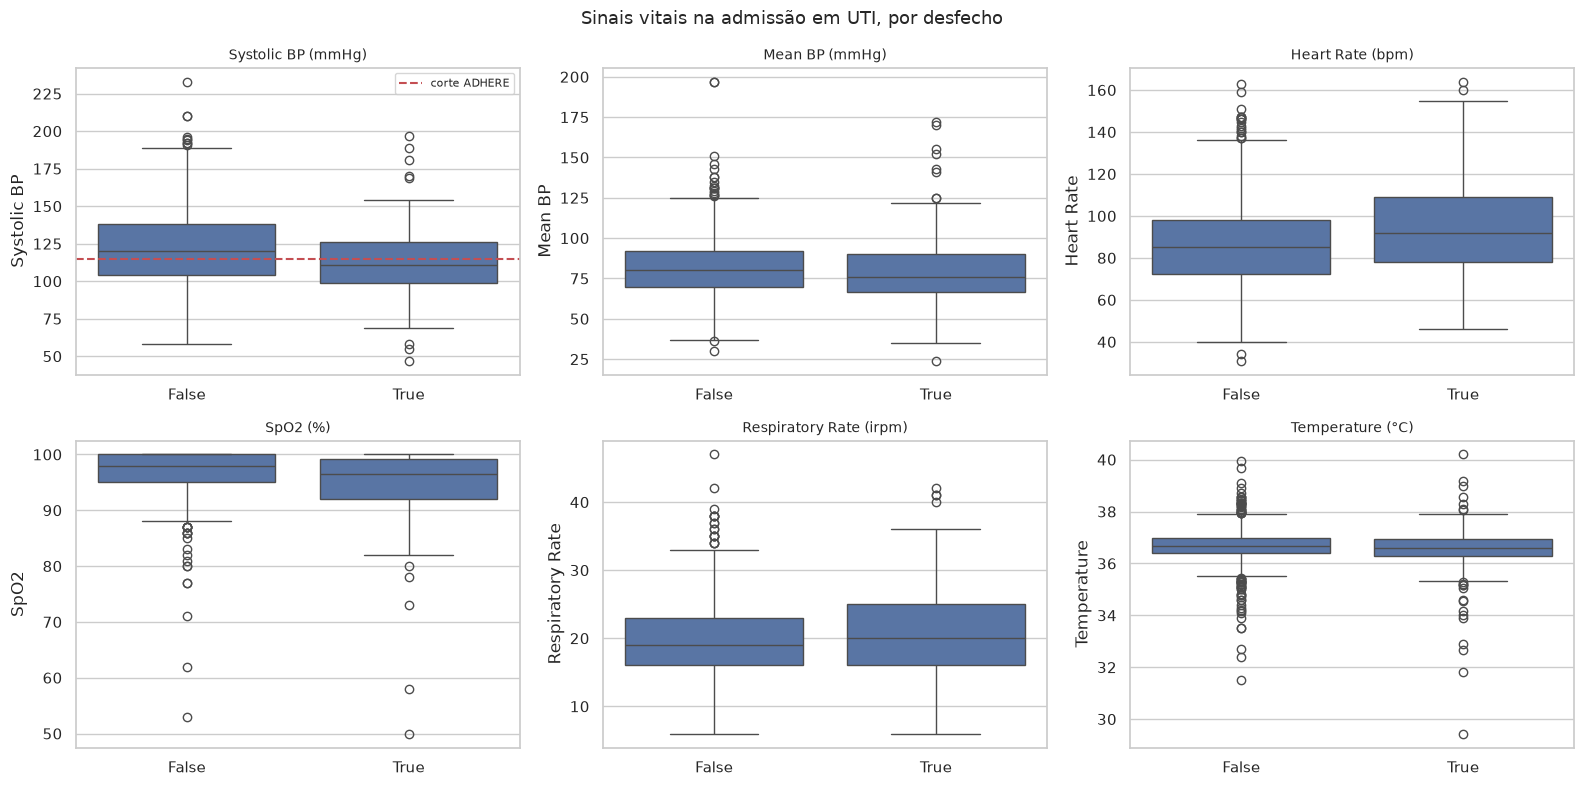

In [23]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

for ax, sinal in zip(axes.flat, SINAIS, strict=False):
    sns.boxplot(data=vitais_desfecho, x=OUTCOME, y=sinal, ax=ax)
    if sinal == "Systolic BP":
        ax.axhline(115, color="C3", linestyle="--", linewidth=1.5, label="corte ADHERE")
        ax.legend(fontsize=8)
    ax.set_title(f"{sinal} ({UNIDADES[sinal]})", fontsize=10)
    ax.set_xlabel("")

fig.suptitle("Sinais vitais na admissão em UTI, por desfecho", fontsize=13)
plt.tight_layout()

abaixo = vitais_desfecho["Systolic BP"] < 115
print(
    f"Internações com pressão sistólica de admissão abaixo de 115 mmHg: "
    f"{int(abaixo.sum())} de {int(vitais_desfecho['Systolic BP'].notna().sum())} "
    f"({abaixo.mean() * 100:.1f}%)"
)
print(f"  mortalidade abaixo do corte: {vitais_desfecho.loc[abaixo, OUTCOME].mean() * 100:.1f}%")
print(f"  mortalidade acima do corte:  {vitais_desfecho.loc[~abaixo, OUTCOME].mean() * 100:.1f}%")

> **Interpretação.** Três leituras, em ordem de importância.
>
> **A separação é fraca individualmente.** Em todos os seis painéis as caixas se sobrepõem quase inteiramente. A caixa cobre os 50% centrais de cada grupo, e no caso da pressão sistólica a dos óbitos está quase toda contida na dos sobreviventes. Olhando a pressão de um paciente qualquer, não daria para dizer o desfecho dele.
>
> **Mas a direção é fisiologicamente coerente, e esse é o achado.** A pressão sistólica cai de 120 para 111 mmHg e a média de 80 para 76; a frequência cardíaca sobe de 85 para 92 e a respiratória de 19 para 20. É o quadro clássico de choque compensado: o coração não bombeia o suficiente, a pressão cai, e o corpo responde acelerando os batimentos e a respiração. O valor não está em nenhum sinal isolado, está em **três medidas independentes apontando na mesma direção**, e em concordância com o que o ânion gap e o bicarbonato mostraram.
>
> **Saturação e temperatura não dizem nada**, com medianas idênticas nos dois grupos. Isso também informa: estes pacientes não morrem por falta de oxigenação nem com febre. Morrem de falha de bombeamento, e a ausência de sinal nessas duas variáveis reforça a hipótese hemodinâmica por eliminação.
>
> Duas ressalvas. A linha do corte do ADHERE separa **grupos**, não pacientes: a mortalidade abaixo de 115 mmHg é 19,3% contra 14,2% acima, mas as duas caixas atravessam a linha. E este é apenas o valor de admissão: quem chegou bem e piorou na décima hora aparece aqui como estável.

### 7.3 Origem da pressão arterial: uma ressalva importante

A pressão pode vir de duas fontes. A **invasiva** usa cateter arterial e é mais precisa; a **não invasiva** usa manguito. O ponto que importa: o cateter só é colocado em pacientes já considerados graves.

Isso reproduz, para a pressão, o mesmo mecanismo de ausência informativa que a seção 4 descreveu para o lactato. A escolha do método de medição carrega o julgamento clínico da equipe, e um modelo que usasse "tem pressão invasiva" como preditor estaria aprendendo essa decisão, não a hemodinâmica do paciente.

In [24]:
origem_pa = (
    vitals_series[vitals_series.sinal == "Systolic BP"]
    .groupby("paciente_id")
    .origem.agg(lambda s: "invasiva" if "invasiva" in set(s) else "nao invasiva")
)
comparacao_origem = pd.DataFrame({"origem": origem_pa}).join(obito)

resumo_origem = (
    comparacao_origem.groupby("origem")
    .agg(internacoes=(OUTCOME, "size"), obitos=(OUTCOME, "sum"))
    .assign(mortalidade_pct=lambda d: (d.obitos / d.internacoes * 100).round(1))
)
print("Mortalidade por método de medição da pressão:\n")
print(resumo_origem.to_string())
print("\nA diferença descreve a gravidade percebida pela equipe, não o efeito da medição.")

Mortalidade por método de medição da pressão:

              internacoes  obitos  mortalidade_pct
origem                                            
invasiva              305      63             20.7
nao invasiva          687      97             14.1

A diferença descreve a gravidade percebida pela equipe, não o efeito da medição.


### 7.4 Escala de Coma de Glasgow

O Glasgow avalia o nível de consciência somando três respostas: abertura ocular (1 a 4), resposta verbal (1 a 5) e resposta motora (1 a 6). O total vai de 3, coma profundo, a 15, plenamente alerta.

Importa aqui por dois motivos. É preditor de mortalidade em terapia intensiva por si só, e é o **componente neurológico** dos escores SOFA e APACHE II, que a seção 8.1 lista como parcialmente disponíveis.

**Duas ressalvas de leitura.** O total só é calculado quando os três componentes foram registrados no mesmo horário; somar componentes de momentos diferentes produziria um escore que nunca existiu. E em paciente intubado a resposta verbal é registrada como sem resposta e pontua 1, o que **subestima** o Glasgow real. A coluna `verbal_intubado` marca esses casos.

5,654 avaliações completas em 996 das 1000 internações
Total: mediana 14, faixa 3 a 15
Avaliações de paciente intubado: 1,400 (24.8%)



Glasgow mediano: 15 entre sobreviventes, 11 entre óbitos
Glasgow abaixo de 15 (algum rebaixamento): 45.3% dos sobreviventes, 65.0% dos óbitos


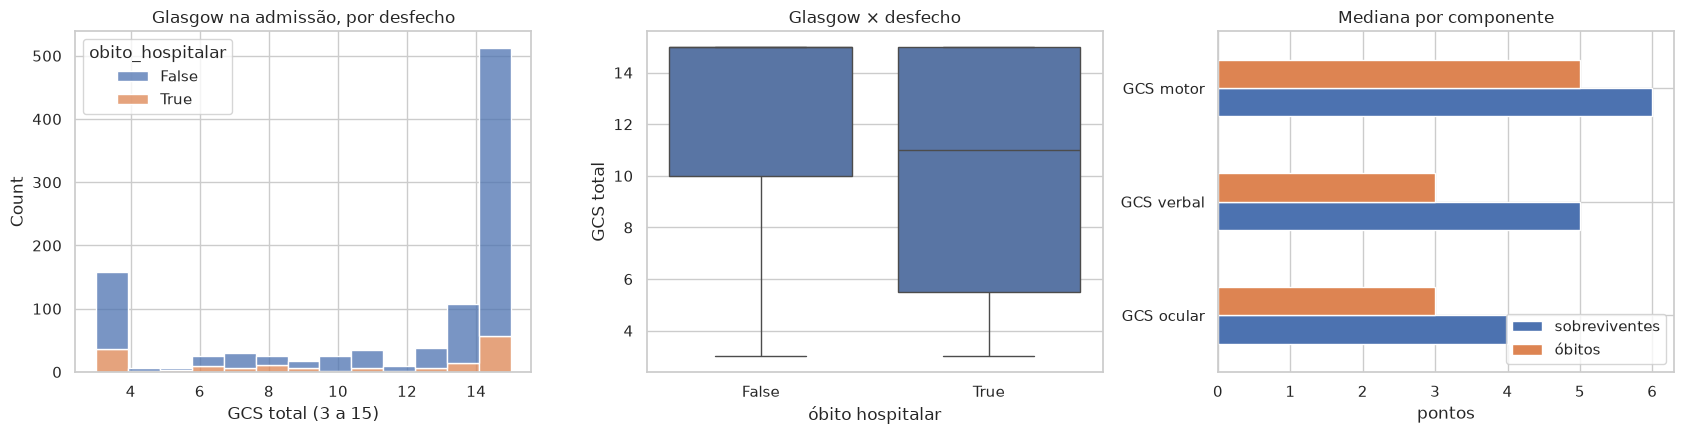

In [25]:
print(
    f"{len(gcs_series):,} avaliações completas em {gcs_series.paciente_id.nunique()} das {n} internações"
)
print(
    f"Total: mediana {gcs_series['GCS total'].median():.0f}, faixa {gcs_series['GCS total'].min():.0f} a {gcs_series['GCS total'].max():.0f}"
)
print(
    f"Avaliações de paciente intubado: {gcs_series.verbal_intubado.sum():,} ({gcs_series.verbal_intubado.mean() * 100:.1f}%)"
)
print()

primeiro_gcs = gcs_series.sort_values("horas_da_janela").groupby("paciente_id").first().join(obito)

fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

sns.histplot(data=primeiro_gcs, x="GCS total", hue=OUTCOME, multiple="stack", bins=13, ax=axes[0])
axes[0].set_title("Glasgow na admissão, por desfecho")
axes[0].set_xlabel("GCS total (3 a 15)")

sns.boxplot(data=primeiro_gcs, x=OUTCOME, y="GCS total", ax=axes[1])
axes[1].set_title("Glasgow × desfecho")
axes[1].set_xlabel("óbito hospitalar")

componentes = ["GCS ocular", "GCS verbal", "GCS motor"]
medianas = pd.DataFrame(
    {
        "sobreviventes": [
            primeiro_gcs.loc[~primeiro_gcs[OUTCOME], c].median() for c in componentes
        ],
        "óbitos": [primeiro_gcs.loc[primeiro_gcs[OUTCOME], c].median() for c in componentes],
    },
    index=componentes,
)
medianas.plot.barh(ax=axes[2])
axes[2].set_title("Mediana por componente")
axes[2].set_xlabel("pontos")

plt.tight_layout()

vivos = primeiro_gcs.loc[~primeiro_gcs[OUTCOME], "GCS total"]
mortos = primeiro_gcs.loc[primeiro_gcs[OUTCOME], "GCS total"]
print(
    f"Glasgow mediano: {vivos.median():.0f} entre sobreviventes, {mortos.median():.0f} entre óbitos"
)
print(
    f"Glasgow abaixo de 15 (algum rebaixamento): "
    f"{(vivos < 15).mean() * 100:.1f}% dos sobreviventes, {(mortos < 15).mean() * 100:.1f}% dos óbitos"
)

> **Interpretação.** O Glasgow separa os grupos com mais clareza que a maioria dos sinais vitais: mediana de 15, o máximo da escala, entre sobreviventes, contra 11 entre óbitos. Algum grau de rebaixamento aparece em 65,0% dos que morreram e em 45,3% dos que sobreviveram.
>
> O histograma mostra por que a mediana esconde parte da história: a distribuição é fortemente concentrada em 15, e o que distingue os grupos é a **cauda inferior**, mais pesada entre os óbitos. O rebaixamento de consciência é a repercussão neurológica da má perfusão cerebral, o mesmo mecanismo que a pressão baixa descreve.
>
> O painel da direita mostra que a diferença entre os grupos vem sobretudo da resposta verbal, e aqui entra a ressalva mais importante: **24,8% das avaliações são de paciente intubado**, situação em que a resposta verbal é registrada como ausente e pontua 1 por convenção, não por avaliação real. Isso subestima o escore de quem está em ventilação mecânica, e como estar intubado é por si só marcador de gravidade, parte da diferença observada pode vir daí. As avaliações estão marcadas para que a etapa seguinte trate esses casos.

### 7.5 Densidade de informação ao longo da janela

As três fontes têm ritmos muito diferentes dentro das mesmas 24 horas, e isso condiciona que tipo de característica cada uma sustenta.

Este gráfico sobrepõe as três: quando cada tipo de dado é registrado, e com que frequência. É a leitura mais direta do que a janela de observação realmente contém.

               fonte  registros  por_internacao  primeira_hora_mediana
exames laboratoriais      73182            73.2                    8.0
       sinais vitais     165667           165.7                   10.7
   escala de Glasgow       5654             5.7                   10.5


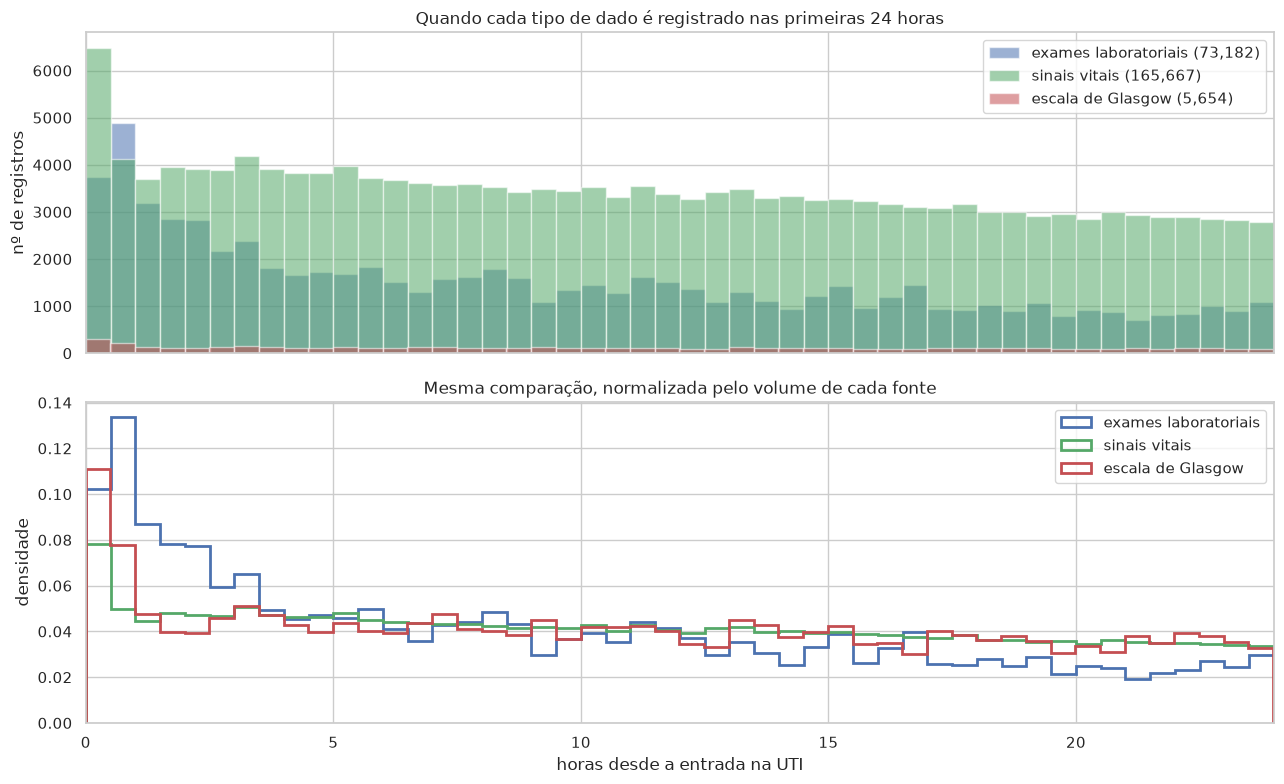

In [26]:
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

fontes = [
    ("exames laboratoriais", medidos.horas_da_janela, "C0"),
    ("sinais vitais", vitals_series.horas_da_janela, "C2"),
    ("escala de Glasgow", gcs_series.horas_da_janela, "C3"),
]

for rotulo, horas, cor in fontes:
    axes[0].hist(horas, bins=48, alpha=0.55, label=f"{rotulo} ({len(horas):,})", color=cor)
axes[0].set_ylabel("nº de registros")
axes[0].set_title("Quando cada tipo de dado é registrado nas primeiras 24 horas", fontsize=12)
axes[0].legend()

# densidade normalizada: compara o ritmo, não o volume
for rotulo, horas, cor in fontes:
    axes[1].hist(
        horas, bins=48, density=True, histtype="step", linewidth=2, label=rotulo, color=cor
    )
axes[1].set_xlabel("horas desde a entrada na UTI")
axes[1].set_ylabel("densidade")
axes[1].set_title("Mesma comparação, normalizada pelo volume de cada fonte", fontsize=12)
axes[1].legend()
axes[1].set_xlim(0, 24)

plt.tight_layout()

resumo_fontes = pd.DataFrame(
    [
        {
            "fonte": rotulo,
            "registros": len(horas),
            "por_internacao": round(len(horas) / n, 1),
            "primeira_hora_mediana": round(horas.median(), 1),
        }
        for rotulo, horas, _ in fontes
    ]
)
print(resumo_fontes.to_string(index=False))

> **Interpretação.** O contraste de densidade é grande: 165,7 registros de sinais vitais por internação, contra 73,2 de exames e 5,7 de Glasgow.
>
> O painel de cima mostra o volume absoluto, dominado pelos sinais vitais. O de baixo normaliza cada fonte pelo próprio total, revelando o **ritmo**: os exames de sangue têm picos marcados, correspondendo à coleta de admissão e à rotina matinal, enquanto os sinais vitais se distribuem de forma mais contínua.
>
> A implicação é que as três fontes sustentam tipos diferentes de característica. Sinais vitais permitem descrever a trajetória dentro da janela; exames de sangue, com uma ou duas medições, descrevem sobretudo o estado. Misturar as duas coisas sob o rótulo genérico de biomarcador dinâmico esconderia essa diferença de qualidade.

## 8. Biomarcadores candidatos

### 8.1 Quadro de candidatos

Um candidato entrou por atender três critérios: plausibilidade biológica, com mecanismo fisiopatológico ligando a variável ao risco de morte e não apenas correlação; precedente em literatura revisada por pares; e mensurabilidade no corte, com completude suficiente.

**Esta seleção vem da literatura, não dos dados.** A exploração das seções 5 e 6 descreve o corte, mas não foi usada para escolher os candidatos. Escolher depois de ver quais dão diferença seria circular, e é a razão de esta etapa não aplicar testes de hipótese.

**As cinco hipóteses que os candidatos operacionalizam** (fundamentação no relatório):

1. **Função renal e ativação neuro-hormonal.** A ureia discrimina risco por refletir hipoperfusão renal, e não apenas filtração glomerular.
2. **Hipoperfusão tecidual.** Ânion gap, bicarbonato e lactato capturam a repercussão sistêmica do baixo débito.
3. **Inflamação e estresse crônicos.** RDW e razão neutrófilos/linfócitos carregam informação que os demais exames não medem.
4. **Fenótipo congestivo.** Achados de congestão radiográfica somam uma medida hemodinâmica. É a mais fraca das cinco.
5. **Instabilidade hemodinâmica e disfunção orgânica.** Pressão baixa e frequência cardíaca elevada indicam débito insuficiente. O rebaixamento de consciência marca a repercussão neurológica da mesma hipoperfusão, mas entra pelo modelo clínico de referência, e não como candidato, pela razão registrada abaixo do quadro.

Atravessando todas: nenhum candidato se sustenta sem ajuste por idade, sob risco de medir envelhecimento com outro nome. Esse ajuste é da etapa seguinte.

| | Candidato | Dado de origem | Hip. | Fundamentação | Como será medido |
|---|---|---|---|---|---|
| **A** | Ureia (BUN) | `Urea Nitrogen` | 1 | Melhor preditor isolado no ADHERE, corte em 43 mg/dL | Contínuo e binária no corte publicado |
| **B** | Razão ureia/creatinina | `Urea Nitrogen` ÷ `Creatinine` | 1 | Isola o componente neuro-hormonal do de filtração | Razão contínua, comparada aos componentes isolados |
| **C** | Creatinina | `Creatinine` | 1 | Disfunção renal na síndrome cardiorrenal; nó da árvore do ADHERE | Contínuo |
| **D** | RDW | `RDW` | 3 | Associado a mortalidade em 9.465 pacientes com IC no MIMIC-IV | Contínuo e binária no corte de 14,96% |
| **E** | Ânion gap e bicarbonato | `Anion Gap`, `Bicarbonate` | 2 | Acidose metabólica por hipoperfusão tecidual | Dois contínuos, testados em conjunto |
| **F** | Lactato | `Lactate` | 2 | Marcador direto de metabolismo anaeróbico | Contínuo, mais indicador de solicitação |
| **G** | Razão neutrófilos/linfócitos | `Neutrophils` ÷ `Lymphocytes` | 3 | Associada a mortalidade em 3.368 pacientes de UTI com IC | Logaritmo da razão, mais indicador de solicitação |
| **H** | Hemoglobina | `Hemoglobin` | 3 | Anemia integra a síndrome cardio-renal-anêmica | Contínuo |
| **I** | Sódio | `Sodium` | 1 | Hiponatremia reflete ativação neuro-hormonal | Contínuo e binária abaixo de 135 mEq/L |
| **J** | Congestão radiográfica | Achados CheXpert | 4 | Escore de admissão não foi significativo na literatura | Suspenso: sem radiografia nesta coorte |
| **K** | Tendência e extremos na janela | Série de 24 h de cada exame | 1 a 3 | O pior valor ou o nível sustentado pode discriminar melhor que a admissão | Valor inicial, média, mínimo, máximo, desvio e tendência |
| **L** | Pressão arterial sistólica | `Systolic BP` | 5 | Segundo melhor preditor no ADHERE, corte em 115 mmHg | Contínuo e binária no corte publicado; média e mínimo da janela |
| **M** | Frequência cardíaca e respiratória | `Heart Rate`, `Respiratory Rate` | 5 | Taquicardia e taquipneia compensam o débito insuficiente | Contínuos, valor de admissão e resumos da janela |

O Glasgow saiu do quadro de candidatos. Pela definição do FDA-NIH Biomarker Working Group, adotada no relatório, biomarcador abrange características moleculares, histológicas, radiográficas e fisiológicas, e exclui avaliações de como o indivíduo se sente, funciona ou sobrevive. Sinais vitais são biomarcadores fisiológicos legítimos, e a pressão arterial é exemplo explícito da definição, o que mantém L e M no quadro; o Glasgow é avaliação clínica graduada por observador e recai na categoria excluída. Ele passa a compor, junto com a idade, o modelo clínico de referência sobre o qual será medido o ganho incremental de cada candidato.

Os candidatos L e M vieram dos sinais vitais, disponíveis a partir do módulo de terapia intensiva. O corte inicial não os tinha, e por isso a quinta hipótese não constava do quadro original.

A completude não está fixada no quadro de propósito: depende do corte carregado e é calculada abaixo.

In [27]:
MENSURAVEIS = {
    "A – Ureia (BUN)": "Urea Nitrogen",
    "C – Creatinina": "Creatinine",
    "D – RDW": "RDW",
    "E – Ânion gap": "Anion Gap",
    "E – Bicarbonato": "Bicarbonate",
    "F – Lactato": "Lactate",
    "G – Neutrófilos": "Neutrophils",
    "G – Linfócitos": "Lymphocytes",
    "H – Hemoglobina": "Hemoglobin",
    "I – Sódio": "Sodium",
}

completude_candidatos = pd.DataFrame(
    [
        {
            "candidato": rotulo,
            "exame": exame,
            "n_presente": int(labs_wide[exame].notna().sum()),
            "completude_%": round(labs_wide[exame].notna().mean() * 100, 1),
        }
        for rotulo, exame in MENSURAVEIS.items()
    ]
).sort_values("completude_%", ascending=False)

print(f"{n} internações no corte\n")
completude_candidatos.reset_index(drop=True)

1000 internações no corte



,candidato,exame,n_presente,completude_%
0,C – Creatinina,Creatinine,983,98.3
1,A – Ureia (BUN),Urea Nitrogen,982,98.2
2,I – Sódio,Sodium,982,98.2
3,E – Ânion gap,Anion Gap,979,97.9
4,E – Bicarbonato,Bicarbonate,979,97.9
5,D – RDW,RDW,971,97.1
6,H – Hemoglobina,Hemoglobin,971,97.1
7,F – Lactato,Lactate,632,63.2
8,G – Linfócitos,Lymphocytes,386,38.6
9,G – Neutrófilos,Neutrophils,386,38.6


#### Panorama: quais candidatos separam os grupos

As seções anteriores mostram um painel por candidato. Esta condensa tudo numa figura só, que é a leitura de conjunto que orienta a seleção.

Para pôr exames de unidades diferentes no mesmo eixo, cada valor é convertido em **desvios em torno da mediana do corte**, usando o intervalo interquartil como escala. É uma padronização robusta: não é afetada por valores extremos, ao contrário do desvio-padrão.

Cada linha liga a mediana dos sobreviventes à dos óbitos. **Quanto mais longa a linha, mais o candidato separa os grupos.** A direção indica o sentido: para a direita, o valor é mais alto em quem morreu.

### 8.2 O que a exploração mostrou

Leitura descritiva das seções 5 e 6. Nenhuma afirmação aqui é resultado de teste estatístico: são diferenças de mediana e separação visual entre distribuições. A avaliação formal, com correção para múltiplas comparações e ajuste por idade, é da etapa seguinte.

**Candidatos com diferença aparente entre os grupos**

- **Ânion gap (E)** e **bicarbonato (E)** aparecem em direções opostas e consistentes entre si: o ânion gap mais alto e o bicarbonato mais baixo entre os óbitos. As duas leituras descrevem a mesma acidose metabólica, o que reforça a coerência da Hipótese 2.
- **Ureia (A)** separa os grupos de forma consistente, coerente com o precedente do ADHERE que motivou a Hipótese 1, ainda que com magnitude menor que a do ânion gap.
- **Lactato (F)** e **creatinina (C)** também separam, com a ressalva de que o lactato só existe em parte da coorte, pelo mecanismo descrito na seção 4.
- **RDW (D)** mostra diferença menor, mas consistente com a literatura em MIMIC-IV.
- **Pressão arterial sistólica (L)** separa os grupos na direção esperada, com mediana de 120 mmHg entre sobreviventes contra 111 entre óbitos. Aplicando o corte de 115 mmHg do ADHERE, a mortalidade é 19,3% abaixo do limiar contra 14,2% acima. É a reprodução independente do segundo melhor preditor daquele registro, e sustenta a Hipótese 5.
- **Frequência cardíaca e respiratória (M)** acompanham na direção esperada, mais altas entre os óbitos. São o correlato taquicárdico e taquipneico do mesmo quadro de débito insuficiente que a pressão descreve.

**Candidatos sem diferença aparente**

- **Hemoglobina (H)**, **sódio (I)** e **plaquetas** têm medianas praticamente iguais entre os grupos, e os gráficos da seção 5.2 mostram as distribuições sobrepostas.
- **Razão ureia/creatinina (B)** separa menos que a ureia isolada, o que não reproduz aqui o ganho sobre os componentes descrito na literatura.
- **Temperatura** tem medianas praticamente idênticas entre os grupos, e a saturação difere em menos de dois pontos percentuais. Nenhuma das duas distingue o desfecho de forma útil nesta coorte.

**Candidatos com ressalva de amostra**

- **Razão neutrófilos/linfócitos (G)** acompanha a direção da literatura, mas o diferencial leucocitário está presente em pouco mais de um terço dos registros. O subconjunto que tem o exame pode não representar a coorte.
- **Tendência e extremos (K)** mostram diferenças na mesma direção do valor de admissão, e em alguns exames a diferença é maior no máximo ou na média do que na chegada. É indício de que vale testar, não evidência de ganho.
- **Congestão radiográfica (J)** segue suspensa por ausência de radiografia no corte.

**A ressalva que vale para todos.** A idade separa fortemente os grupos nesta coorte, e nada aqui está ajustado por ela. Parte da diferença atribuída a um candidato pode ser idade. Separar as duas coisas é a primeira tarefa da etapa seguinte.

Ordenados por separação (o Glasgow consta como referência, não como candidato):
              variavel  separacao
             Anion Gap      0.600
GCS total (referência)     -0.571
           Bicarbonate     -0.500
                   RDW      0.467
     White Blood Cells      0.417
            Creatinine      0.417
         Urea Nitrogen      0.370
           Systolic BP     -0.281
            Heart Rate      0.269
                  SpO2     -0.250
               Lactate      0.200
      Respiratory Rate      0.143
        Platelet Count      0.070
            Hemoglobin     -0.033
                Sodium      0.000


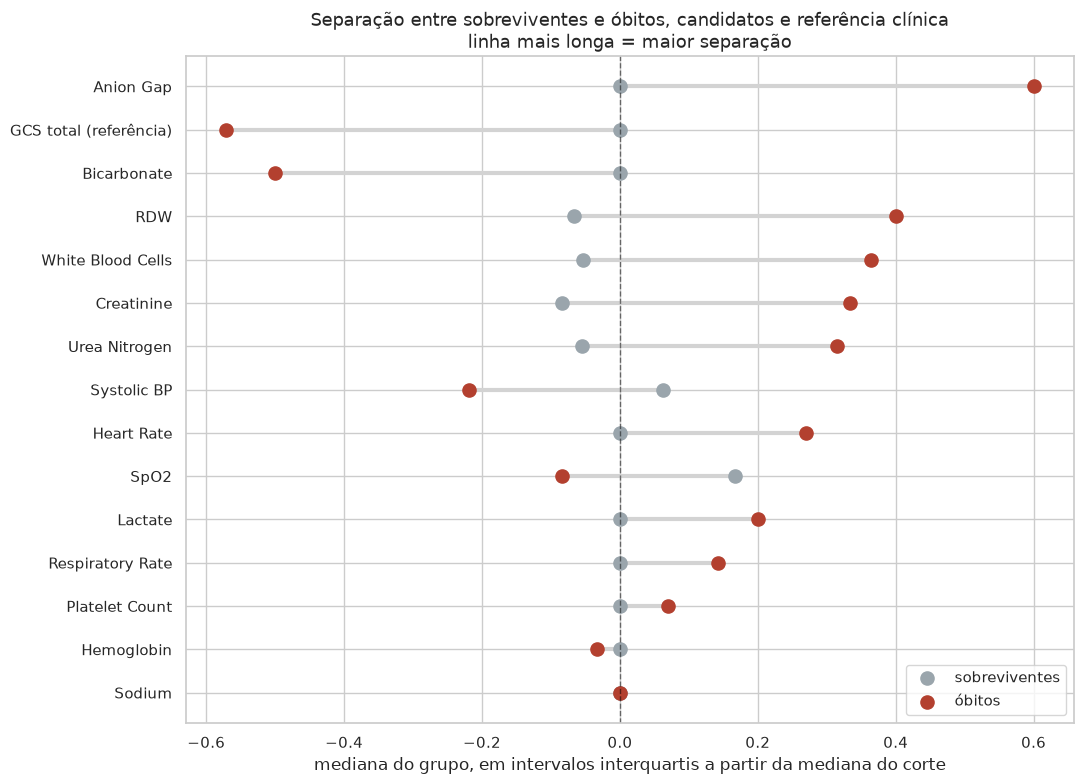

In [28]:
TODOS = CANDIDATOS + ["Systolic BP", "Heart Rate", "Respiratory Rate", "SpO2"]

# junta exames e sinais vitais numa tabela só, usando o primeiro valor de cada
base = (
    labs_wide[CANDIDATOS]
    .join(primeiro_vital[["Systolic BP", "Heart Rate", "Respiratory Rate", "SpO2"]])
    .join(primeiro_gcs[["GCS total"]])
    .join(obito)
)
# o Glasgow entra como referência, e não como candidato: é o comparador contra o
# qual o ganho de cada candidato será medido (seção 8.1)
REFERENCIA = ["GCS total"]
TODOS = TODOS + REFERENCIA

linhas = []
for variavel in TODOS:
    serie = base[variavel].dropna()
    mediana, iqr = serie.median(), serie.quantile(0.75) - serie.quantile(0.25)
    if iqr == 0:
        continue
    padronizado = (serie - mediana) / iqr
    grupo = base.loc[serie.index, OUTCOME]
    linhas.append(
        {
            "variavel": variavel,
            "sobreviventes": padronizado[~grupo].median(),
            "obitos": padronizado[grupo].median(),
        }
    )

panorama = pd.DataFrame(linhas)
panorama["separacao"] = panorama.obitos - panorama.sobreviventes
panorama = panorama.reindex(panorama.separacao.abs().sort_values().index)

fig, ax = plt.subplots(figsize=(11, 8))
y = range(len(panorama))

ax.hlines(y, panorama.sobreviventes, panorama.obitos, color="lightgray", linewidth=3, zorder=1)
ax.scatter(panorama.sobreviventes, y, s=90, color="#9AA5AC", label="sobreviventes", zorder=2)
ax.scatter(panorama.obitos, y, s=90, color="#B3402F", label="óbitos", zorder=2)

ax.axvline(0, color="black", linewidth=1, linestyle="--", alpha=0.5)
ax.set_yticks(list(y))
rotulos = [f"{v} (referência)" if v in REFERENCIA else v for v in panorama.variavel]
ax.set_yticklabels(rotulos)
ax.set_xlabel("mediana do grupo, em intervalos interquartis a partir da mediana do corte")
ax.set_title(
    "Separação entre sobreviventes e óbitos, candidatos e referência clínica\n"
    "linha mais longa = maior separação",
    fontsize=13,
)
ax.legend(loc="lower right")
plt.tight_layout()

print("Ordenados por separação (o Glasgow consta como referência, não como candidato):")
print(
    panorama.iloc[::-1][["variavel", "separacao"]]
    .assign(
        variavel=lambda d: d.variavel.map(lambda v: f"{v} (referência)" if v in REFERENCIA else v),
        separacao=lambda d: d.separacao.round(3),
    )
    .to_string(index=False)
)

> **Interpretação.** Esta é a figura-síntese da seleção de candidatos, e ordena tudo o que foi explorado. O Glasgow aparece no gráfico como referência, e não como candidato: serve de régua, porque é sobre ele e a idade que o ganho de cada candidato será medido.
>
> **Ânion gap lidera com folga entre os candidatos** (0,600), seguido do bicarbonato (-0,500). Os dois descrevem o mesmo eixo em direções opostas, a acidose por má perfusão. A liderança do ânion gap é coerente com ele ser uma medida composta, que integra o efeito de vários distúrbios de uma vez.
>
> **A régua é exigente.** O Glasgow (-0,571) separa mais que qualquer candidato exceto o ânion gap, e mede a repercussão da mesma hipoperfusão sobre o cérebro. É exatamente por isso que ele compõe o modelo de referência: um candidato só é clinicamente útil se acrescentar informação sobre o que a avaliação de beira-leito já fornece.
>
> Logo atrás vêm RDW (0,467), leucócitos (0,417), creatinina (0,417) e ureia (0,370).
>
> **Os sinais vitais aparecem no meio da tabela**, com a pressão sistólica em -0,281 e a frequência cardíaca em 0,269. Menor que a dos exames laboratoriais líderes, o que contraria a expectativa de quem imaginaria a pressão arterial como o marcador mais óbvio de gravidade.
>
> **Três candidatos praticamente não separam**: sódio com separação zero, hemoglobina em -0,033 e plaquetas em 0,070. A leitura honesta é que não sustentam hipótese nesta coorte, e isso precisa constar do relatório com a mesma clareza dos que funcionaram.
>
> O sinal negativo em Glasgow, bicarbonato, pressão sistólica e saturação indica apenas a direção: nesses, o valor é **mais baixo** entre quem morreu, o que é o esperado para os quatro.

#### Redundância entre candidatos

Dois candidatos que medem a mesma coisa não somam informação, e colocá-los juntos num modelo cria colinearidade. Esta matriz descreve o quanto cada par varia junto, pela correlação de postos, que não supõe distribuição normal nem relação linear.

Não é teste de hipótese: é descrição da estrutura dos dados, e serve para decidir quais candidatos são complementares e quais são substitutos um do outro.

O que esperar pela fisiologia: ureia e creatinina devem correlacionar, porque as duas passam pelo rim; ânion gap e bicarbonato devem correlacionar **negativamente**, porque um sobe quando o outro é consumido; pressão sistólica e média devem ser quase redundantes, por construção.

Pares mais correlacionados (candidatos a redundância):
            a                b  correlacao
Urea Nitrogen       Creatinine        0.75
   Creatinine        Anion Gap        0.50
    Anion Gap      Bicarbonate       -0.44
Urea Nitrogen        Anion Gap        0.42
   Heart Rate Respiratory Rate        0.33
          RDW       Hemoglobin       -0.31
Urea Nitrogen              RDW        0.30
  Bicarbonate          Lactate       -0.30


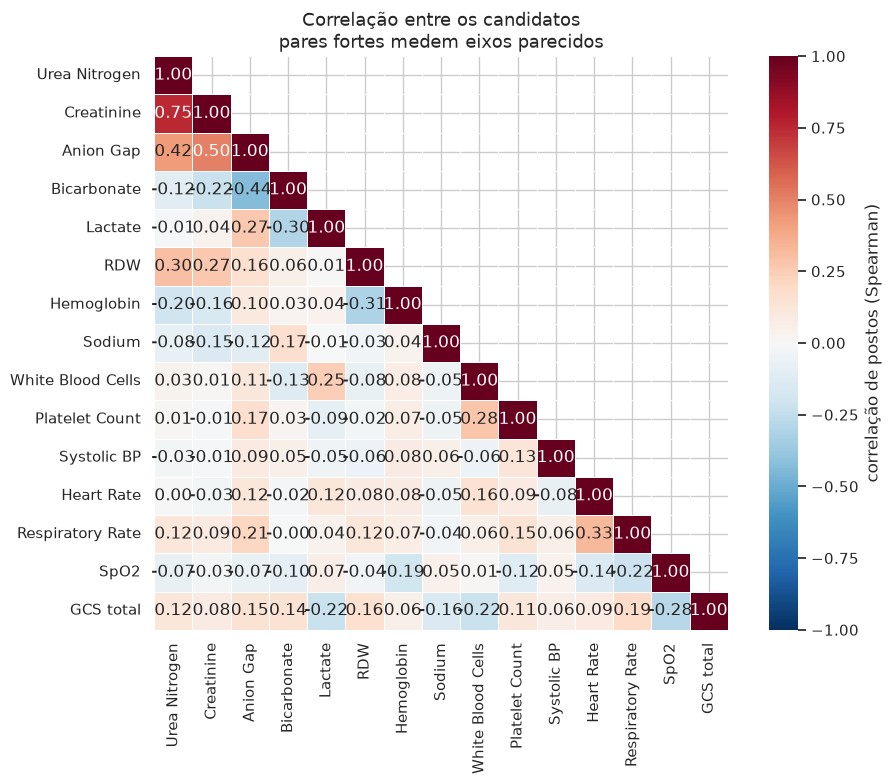

In [29]:
correlacao = base[TODOS].corr(method="spearman")

fig, ax = plt.subplots(figsize=(10, 8))
mascara = np.triu(np.ones_like(correlacao, dtype=bool), k=1)
sns.heatmap(
    correlacao,
    mask=mascara,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={"label": "correlação de postos (Spearman)"},
    ax=ax,
)
ax.set_title("Correlação entre os candidatos\npares fortes medem eixos parecidos", fontsize=13)
plt.tight_layout()

# pares mais redundantes, para a decisão do quadro: só o triângulo superior,
# porque a matriz é simétrica e a diagonal é sempre 1
linhas_i, colunas_j = np.triu_indices(len(correlacao), k=1)
pares = pd.DataFrame(
    {
        "a": correlacao.index[linhas_i],
        "b": correlacao.columns[colunas_j],
        "correlacao": correlacao.to_numpy()[linhas_i, colunas_j].round(2),
    }
)
print("Pares mais correlacionados (candidatos a redundância):")
print(
    pares.reindex(pares.correlacao.abs().sort_values(ascending=False).index)
    .head(8)
    .to_string(index=False)
)

> **Interpretação.** A matriz confirma o que a fisiologia previa, e traz uma consequência prática para o quadro de candidatos.
>
> **Ureia e creatinina correlacionam a 0,75**, que é alto. As duas passam pelo rim e sobem juntas, então carregam informação largamente sobreposta. Colocar as duas num mesmo modelo criaria colinearidade, e o efeito de uma seria atribuído à outra de forma instável. A decisão razoável é escolher uma como candidata principal e tratar a outra como alternativa, ou usar a razão entre elas, que é justamente o candidato B.
>
> **Ânion gap e bicarbonato dão −0,44**, negativo como esperado: um sobe quando o outro é consumido. São as duas faces da mesma acidose, e a mesma ressalva de redundância se aplica.
>
> O que interessa igualmente são as correlações **fracas**. O RDW, por exemplo, tem correlação de apenas 0,30 com a ureia, o que sugere que mede um eixo diferente, provavelmente inflamação e doença crônica. Candidatos pouco correlacionados entre si são os que têm chance real de somar informação num modelo conjunto.

### 8.3 Operacionalização computacional preliminar

Como cada candidato vira uma coluna analisável, e que decisões isso exige.

**Extração.** Cada internação vira um vetor. Cada candidato gera uma coluna contínua com o valor mais precoce da janela e, quando há corte publicado, a binária correspondente: ureia a partir de 43 mg/dL, RDW a partir de 14,96%, sódio abaixo de 135 mEq/L, pressão sistólica abaixo de 115 mmHg. Sobre a série de 24 horas, cada exame e cada sinal vital geram adicionalmente as leituras do candidato K.

**Sinais vitais exigem um cuidado próprio.** São medidos dezenas de vezes por dia, contra uma ou duas dos exames de sangue, então a média e o mínimo da janela são estimativas bem mais estáveis que as dos exames. Em compensação, a pressão arterial tem duas origens: quando vier de cateter arterial, o registro precisa acompanhar a variável, porque a escolha do método reflete gravidade percebida.

**Ausentes.** Três regimes conforme a completude. Acima de 95%, imputação pela mediana com análise de sensibilidade sem imputação. Lactato e razão neutrófilos/linfócitos recebem também uma variável indicadora de presença do exame, tratando a solicitação como informação. Acima de 50% de ausência, o exame fica fora dos modelos. O indicador de presença do exame é proxy do julgamento clínico da equipe, e não da fisiologia do paciente, conforme a ressalva da seção 4.3. Por isso os modelos serão reportados em duas versões, com e sem o indicador, e qualquer ganho atribuído a ele será interpretado como informação sobre a decisão de solicitar, não sobre o doente.

**Análise.** Testes não paramétricos, dada a assimetria das distribuições vista na seção 5, sempre com tamanho de efeito e intervalo de confiança. Correção para múltiplas comparações por Benjamini-Hochberg, já que são dez candidatos testados.

**Modelagem.** Regressão logística ajustada por idade e Glasgow, que compõem o modelo clínico de referência. O ganho de cada candidato sobre esse modelo é medido por área sob a curva ROC e teste da razão de verossimilhança. A pergunta que isso responde é a de utilidade clínica: se o candidato acrescenta informação ao que a avaliação de beira-leito já fornece.

**Vazamento.** Duas variáveis só são conhecidas no fim da internação e ficam fora dos preditores: o local de destino da alta, que contém a categoria de óbito, e o tempo de permanência. Servem apenas para caracterizar a coorte.

A célula abaixo monta a matriz de características resultante, que é o insumo da etapa seguinte.

In [30]:
UREA_CUTOFF, RDW_CUTOFF, SODIUM_CUTOFF = 43.0, 14.96, 135.0

X = pd.DataFrame(index=labs_wide.index)

X["Urea Nitrogen"] = labs_wide["Urea Nitrogen"]
X["Creatinine"] = labs_wide["Creatinine"]
X["urea_creatinine_ratio"] = X["Urea Nitrogen"] / X["Creatinine"]
X["Anion Gap"] = labs_wide["Anion Gap"]
X["Bicarbonate"] = labs_wide["Bicarbonate"]
X["RDW"] = labs_wide["RDW"]
X["Hemoglobin"] = labs_wide["Hemoglobin"]
X["Sodium"] = labs_wide["Sodium"]

X["Lactate"] = labs_wide["Lactate"]
X["lactate_measured"] = labs_wide["Lactate"].notna().astype(int)

razao_nlr = labs_wide["Neutrophils"] / labs_wide["Lymphocytes"]
X["ln_nlr"] = np.log(razao_nlr.where(razao_nlr > 0))
X["nlr_measured"] = razao_nlr.notna().astype(int)

# binárias dos cortes publicados; a ausência precisa ser propagada, porque
# comparar NaN com um número devolve False e viraria "abaixo do corte"
for coluna, origem, corte, acima in [
    ("high_urea", "Urea Nitrogen", UREA_CUTOFF, True),
    ("high_rdw", "RDW", RDW_CUTOFF, True),
    ("hyponatremia", "Sodium", SODIUM_CUTOFF, False),
]:
    X[coluna] = (X[origem] >= corte if acima else X[origem] < corte).astype("Int64")
    X.loc[X[origem].isna(), coluna] = pd.NA

# sinais vitais e Glasgow: o quadro de candidatos inclui L, M e o modelo de
# referência, então a matriz precisa carregá-los
X = X.join(primeiro_vital[["Systolic BP", "Heart Rate", "Respiratory Rate", "SpO2"]])
X = X.join(primeiro_gcs[["GCS total"]])

X["low_sbp"] = (X["Systolic BP"] < 115).astype("Int64")
X.loc[X["Systolic BP"].isna(), "low_sbp"] = pd.NA

X["idade"] = cohort.set_index("paciente_id")["idade"]
X[OUTCOME] = cohort.set_index("paciente_id")[OUTCOME].astype(int)

print(f"Matriz: {X.shape[0]} registros × {X.shape[1] - 1} colunas, mais o desfecho")
print(f"Desfecho: {int(X[OUTCOME].sum())} óbitos ({X[OUTCOME].mean() * 100:.1f}%)\n")
pd.DataFrame(
    {
        "n_presente": X.notna().sum(),
        "completude_%": (X.notna().mean() * 100).round(1),
    }
).sort_values("completude_%", ascending=False)

Matriz: 1000 registros × 22 colunas, mais o desfecho
Desfecho: 165 óbitos (16.5%)



,n_presente,completude_%
Respiratory Rate,1000,100.0
idade,1000,100.0
obito_hospitalar,1000,100.0
Heart Rate,1000,100.0
lactate_measured,1000,100.0
nlr_measured,1000,100.0
SpO2,999,99.9
GCS total,996,99.6
Systolic BP,992,99.2
low_sbp,992,99.2
